In [28]:
# start date 27/02/2025

import numpy as np
import math
import pandas as pd
import cv2
import os
import re
from pdf2image import convert_from_path 
#import tqdm
#from scipy.io import loadmat

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

from PIL import Image
# import pytesseract

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import backend as K

# from utils import *

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from keras.layers import *

# from keras.applications import MobileNetV2
# from keras.applications import InceptionResNetV2

from keras.models import Model
from keras.models import model_from_json
from keras import regularizers

#from keras.initializers import he_normal

from keras.models import load_model
from math import sqrt


In [2]:
target_size = [500, 700]

target_w = 700 # target sizes of image in model input
target_h = 500 #target sizes of image in model input

class_num = 1     ## item

categories = ['bom'] # details of classes

In [3]:
# Loading output of VGG Image Annotation tool and create a dataframe

region_data = []
r_data = pd.DataFrame()
r_data_master = pd.DataFrame()

for i in range(1, 27):
    via_folder = '/Users/subrata/workstation/jupyterFiles/yolo_data_file/via_region_data_drg_test_' + str(i) + '.csv'
    region = pd.read_csv(via_folder)
    region_data.append(region)

r_data = pd.concat(region_data).reset_index()
print(len(r_data))
r_data_master = r_data[~r_data['region_shape_attributes'].str.contains('{}')].reset_index(drop=True) # remove drgs having no bbox info
# r_data_master = r_data[~r_data['region_attributes'].str.contains('{}')].reset_index(drop=True) # remove drgs having no bbox info
print(len(r_data_master))  
r_data_master_unique = r_data_master.drop_duplicates('#filename', keep=False).reset_index(drop=True) # remove duplicate rows
print('==========================')
print(len(r_data_master_unique))
r_data_master_unique.drop(r_data_master_unique.columns[[0, 2, 3, 4, 5]], axis=1, inplace=True) # reduce unnecessary columns

num_images_in_data_master = r_data_master_unique["#filename"].nunique()
r_data_master_image_list = r_data_master_unique["#filename"].tolist()

print(num_images_in_data_master)
r_data_master_unique.head()


1428
1428
1406
1406


,#filename,region_shape_attributes,region_attributes
0,1001.jpg,"{""name"":""rect"",""x"":2290,""y"":1257,""width"":1015,...","{""text"":""bom""}"
1,1002.jpg,"{""name"":""rect"",""x"":2171,""y"":1401,""width"":1142,...","{""text"":""bom""}"
2,1003.jpg,"{""name"":""rect"",""x"":2094,""y"":1224,""width"":1215,...","{""text"":""bom""}"
3,1004.jpg,"{""name"":""rect"",""x"":2284,""y"":1648,""width"":1025,...","{""text"":""bom""}"
4,1005.jpg,"{""name"":""rect"",""x"":2280,""y"":1700,""width"":1029,...","{""text"":""bom""}"


In [3]:
r_data_master_unique.tail(10)

,#filename,region_shape_attributes,region_attributes
1396,EMM1-15-RC105-17-Model-page-001.jpg,"{""name"":""rect"",""x"":0,""y"":0,""width"":0,""height"":0}",{}
1397,EMM1-15-RC105-18-Model-page-001.jpg,"{""name"":""rect"",""x"":665,""y"":2339,""width"":1670,""...","{""bom"":""""}"
1398,EMM1-15-RC105-19-Model-page-001.jpg,"{""name"":""rect"",""x"":0,""y"":0,""width"":0,""height"":0}",{}
1399,EMM1-15-RC105-22-Model-page-001.jpg,"{""name"":""rect"",""x"":0,""y"":0,""width"":0,""height"":0}",{}
1400,EMM1-15-RC105-23-Model-page-001.jpg,"{""name"":""rect"",""x"":0,""y"":0,""width"":0,""height"":0}",{}
1401,EMM1-15-RC105-25-Model-page-001.jpg,"{""name"":""rect"",""x"":0,""y"":0,""width"":0,""height"":0}",{}
1402,EMM1-15-RC105-27-Model-page-001.jpg,"{""name"":""rect"",""x"":0,""y"":0,""width"":0,""height"":0}",{}
1403,SOM 14 003437 MHIL-Model-1-page-001.jpg,"{""name"":""rect"",""x"":0,""y"":0,""width"":0,""height"":0}",{}
1404,SOM 14 003437 MHIL-Model-2-page-001.jpg,"{""name"":""rect"",""x"":0,""y"":0,""width"":0,""height"":0}",{}
1405,SOM 14 003437 MHIL-Model-page-001.jpg,"{""name"":""rect"",""x"":0,""y"":0,""width"":0,""height"":0}",{}


In [4]:
print(r_data_master_unique.isnull().any())   ## check whether any Nan value in any cell
print('==============')
print(r_data_master_unique.eq(0).any())  ## check whether any '0' value in any cell


#filename                  False
region_shape_attributes    False
region_attributes          False
dtype: bool
#filename                  False
region_shape_attributes    False
region_attributes          False
dtype: bool


In [4]:
## make an image list

num_image_folder = []
drg_image = []

for i in range(1, 27):
    drg_folder = 'drg_test_' + str(i)
    drg_directory = '/Users/subrata/workstation/jupyterFiles/yolo_data_file/' + drg_folder

    drg_folder = [os.path.join(drg_directory, f) for f in os.listdir(drg_directory)if not f.startswith('.')]  # Ignore hidden files like .DS_Store
 #   inter_var_1 = drg_directory + '/{}'
 #   drg_folder = [inter_var_1.format(i) for i in os.listdir(drg_directory)]
    num_image_folder.append(len(drg_folder))
    drg_image.append(drg_folder)

print('Number of images in folders = ', num_image_folder)
num_images = len(drg_image)
print('Number of image folders = ', num_images)


Number of images in folders =  [35, 35, 36, 39, 35, 39, 35, 53, 54, 40, 106, 54, 61, 53, 98, 97, 95, 99, 12, 45, 45, 45, 47, 46, 66, 58]
Number of image folders =  26


In [5]:
## drg_image above is a list of lists. We need to flatten this and create a dataframe: 

from itertools import chain

drg_image_path_df_original = pd.DataFrame()
k = []
drg_image_1 = []

k = list(chain.from_iterable(map(list, drg_image)))
drg_image_1 = k
drg_image_1.sort() # Sorting the list

print(len(drg_image_1))

drg_image_path_values = pd.Series(drg_image_1)
drg_image_path_df_original.insert(loc=0, column='i_path', value = drg_image_path_values)

print(len(drg_image_path_df_original))
drg_image_path_df_original.tail(3)



1428
1428


,i_path
1425,/Users/subrata/workstation/jupyterFiles/yolo_d...
1426,/Users/subrata/workstation/jupyterFiles/yolo_d...
1427,/Users/subrata/workstation/jupyterFiles/yolo_d...


In [6]:
# remove duplicate drawings across folders and create a column for only drg. no.

drg_image_path_df = pd.DataFrame()

drg_image_path_df_original['drg_no'] = drg_image_path_df_original['i_path'].apply(lambda x: x.split('/')[-1])

print(len(drg_image_path_df_original))
print('===========================')
#drg_image_path_df = drg_image_path_df_original.drop_duplicates(subset='drg_no').reset_index(drop=True)
#print(len(drg_image_path_df))
# drg_image_path_df = drg_image_path_df.drop('drg_no', axis=1)
# drg_image_path_df.tail(3)
drg_image_path_df = drg_image_path_df_original.drop_duplicates('drg_no', keep=False).reset_index(drop=True) # remove duplicate rows
print(len(drg_image_path_df))
# Check if '#filename' column in r_data_master_unique and 'drg_no' column in drg_image_path_df are having identical values in all rows:

# Convert columns to sets
set_df1 = set(r_data_master_unique['#filename'])
set_df2 = set(drg_image_path_df['drg_no'])

# Find mismatches
extra_in_df1 = set_df1 - set_df2  # Values present in df1 but not in df2
extra_in_df2 = set_df2 - set_df1  # Values present in df2 but not in df1

# Display results
if not extra_in_df1 and not extra_in_df2:
    print("✅ All values match (ignoring order)!")
else:
    print("❌ Mismatches found:")
    if extra_in_df1:
        print(f"Present in df1 but missing in df2: {extra_in_df1}")
    if extra_in_df2:
        print(f"Present in df2 but missing in df1: {extra_in_df2}")

1428
1406
✅ All values match (ignoring order)!


In [8]:
# merge two data frames on drg.no. or file name and create a combined dataframe with required columns :
merged_drg_data = pd.DataFrame()
merged_drg_data = pd.merge(drg_image_path_df.rename(columns={'drg_no': '#filename'}), r_data_master_unique, on='#filename')
merged_drg_data.tail(3)


,i_path,#filename,region_shape_attributes,region_attributes
1403,/Users/subrata/workstation/jupyterFiles/yolo_d...,10834-2-20-SWZ-01-11-Model-page-001.jpg,"{""name"":""rect"",""x"":1161,""y"":513,""width"":500,""h...","{""text"":""bom""}"
1404,/Users/subrata/workstation/jupyterFiles/yolo_d...,10834-2-20-SWZ-04-00-Model-page-001.jpg,"{""name"":""rect"",""x"":1051,""y"":709,""width"":608,""h...","{""text"":""bom""}"
1405,/Users/subrata/workstation/jupyterFiles/yolo_d...,10834-2-20-SWZ-04-02-Model-page-001.jpg,"{""name"":""rect"",""x"":1138,""y"":874,""width"":517,""h...","{""text"":""bom""}"


In [9]:
merged_drg_data[1001:1005]

,i_path,#filename,region_shape_attributes,region_attributes
1001,/Users/subrata/workstation/jupyterFiles/yolo_d...,004379GPIL-Model-17-page-001.jpg,"{""name"":""rect"",""x"":250,""y"":1585,""width"":1614,""...","{""bom"":""""}"
1002,/Users/subrata/workstation/jupyterFiles/yolo_d...,004379GPIL-Model-18-page-001.jpg,"{""name"":""rect"",""x"":250,""y"":1957,""width"":1856,""...","{""bom"":""""}"
1003,/Users/subrata/workstation/jupyterFiles/yolo_d...,004379GPIL-Model-19-page-001.jpg,"{""name"":""rect"",""x"":250,""y"":1779,""width"":1614,""...","{""bom"":""""}"
1004,/Users/subrata/workstation/jupyterFiles/yolo_d...,004379GPIL-Model-2-page-001.jpg,"{""name"":""rect"",""x"":0,""y"":0,""width"":0,""height"":0}",{}


In [9]:
r_size = merged_drg_data.values[1403, 2][1:(len(merged_drg_data.values[1403, 2])-1)]
r_size_par = r_size.split(",")
print(r_size_par)

r_attribs_1 = merged_drg_data.values[1001, 3][1:(len(merged_drg_data.values[1001, 3])-1)]
r_attribs_2 = merged_drg_data.values[1403, 3][1:(len(merged_drg_data.values[1403, 3])-1)]
r_attribs_3 = merged_drg_data.values[1004, 3][1:(len(merged_drg_data.values[1004, 3])-1)]
print(r_attribs_1)
print(r_attribs_2)
print(r_attribs_3)

['"name":"rect"', '"x":1161', '"y":513', '"width":500', '"height":426']
"bom":""
"text":"bom"



In [10]:
# Making a dataframe for Image_id, image path, x, y, width, height, class, image_width, image_height :

x = []  # co-ordinate of bbox left-top corner (and NOT center of bbox) as given by via
y = []  # co-ordinate of bbox left-top corner (and NOT center of bbox) as given by via
width = []  # of boundary box
height = []  # of boundary box
obj_class = []
i_width = []
i_height = []
img_path = []

for i in range(len(merged_drg_data)):
    
    # for x, y, width, height of boundary box:
    r_size = merged_drg_data.values[i, 2][1:(len(merged_drg_data.values[i, 2])-1)]
    r_size_par = r_size.split(",")
    x.append(int("".join(filter(str.isdigit, r_size_par[1]))))
    y.append(int("".join(filter(str.isdigit, r_size_par[2]))))
    width.append(int("".join(filter(str.isdigit, r_size_par[3]))))
    height.append(int("".join(filter(str.isdigit, r_size_par[4]))))
    
    # for object class :
    r_attribs = merged_drg_data.values[i, 3][1:(len(merged_drg_data.values[i, 3])-1)]
    if r_attribs == '':
        this_class = 0
    else:
        this_class = 1
    obj_class.append(this_class)
    
    # for image width, height :
    foto_path = merged_drg_data.values[i,0]
    bgr_image = cv2.imread(foto_path)
    image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
    i_ht, i_wd, _ = image.shape
    i_height.append(i_ht)
    i_width.append(i_wd)

# making the dataframe :    
x_values = pd.Series(x)
y_values = pd.Series(y)
width_values = pd.Series(width)
height_values = pd.Series(height)
class_values = pd.Series(obj_class)
i_width_values = pd.Series(i_width)
i_height_values = pd.Series(i_height)

merged_drg_data.insert(loc=2, column='x', value=x_values)
merged_drg_data.insert(loc=3, column='y', value=y_values)
merged_drg_data.insert(loc=4, column='width', value=width_values)
merged_drg_data.insert(loc=5, column='height', value=height_values)
merged_drg_data.insert(loc=6, column='obj_class', value=class_values)
merged_drg_data.insert(loc=7, column='img_wd', value=i_width_values)
merged_drg_data.insert(loc=8, column='img_ht', value=i_height_values)

merged_drg_data.drop(merged_drg_data.columns[[9, 10]], axis=1, inplace=True) # reduce unnecessary columns
merged_drg_data.rename({'#filename': 'img_id'}, axis=1, inplace=True) # changing column name

merged_drg_data.tail(3)


,i_path,img_id,x,y,width,height,obj_class,img_wd,img_ht
1403,/Users/subrata/workstation/jupyterFiles/yolo_d...,10834-2-20-SWZ-01-11-Model-page-001.jpg,1161,513,500,426,1,1754,1240
1404,/Users/subrata/workstation/jupyterFiles/yolo_d...,10834-2-20-SWZ-04-00-Model-page-001.jpg,1051,709,608,229,1,1754,1240
1405,/Users/subrata/workstation/jupyterFiles/yolo_d...,10834-2-20-SWZ-04-02-Model-page-001.jpg,1138,874,517,71,1,1754,1240


In [12]:
df_1 = merged_drg_data[1001:1005]
df_1.head()

,i_path,img_id,x,y,width,height,obj_class,img_wd,img_ht
1001,/Users/subrata/workstation/jupyterFiles/yolo_d...,004379GPIL-Model-17-page-001.jpg,250,1585,1614,525,1,3508,2479
1002,/Users/subrata/workstation/jupyterFiles/yolo_d...,004379GPIL-Model-18-page-001.jpg,250,1957,1856,148,1,3508,2479
1003,/Users/subrata/workstation/jupyterFiles/yolo_d...,004379GPIL-Model-19-page-001.jpg,250,1779,1614,330,1,3508,2479
1004,/Users/subrata/workstation/jupyterFiles/yolo_d...,004379GPIL-Model-2-page-001.jpg,0,0,0,0,0,3508,2479


In [11]:
# find drawing of maximum size
df = merged_drg_data.sort_values('img_wd', ascending=False)
df.head(5)

,i_path,img_id,x,y,width,height,obj_class,img_wd,img_ht
332,/Users/subrata/workstation/jupyterFiles/yolo_d...,5305-7-14-FRF-01-03 SH1-Model-page-001.jpg,5894,2774,3511,2302,1,10200,6600
335,/Users/subrata/workstation/jupyterFiles/yolo_d...,5305-7-14-FRF-01-06 SH1-Model-page-001.jpg,7345,2855,2153,2648,1,10200,6600
336,/Users/subrata/workstation/jupyterFiles/yolo_d...,5305-7-14-FRF-01-07-Model-page-001.jpg,7391,4191,2107,1335,1,10200,6600
378,/Users/subrata/workstation/jupyterFiles/yolo_d...,6070-15-SRZ-01-06 SH1-page-001.jpg,2999,1830,1732,832,1,4963,3508
15,/Users/subrata/workstation/jupyterFiles/yolo_d...,1016.jpg,3005,2234,1726,441,1,4963,3508


In [12]:
#since there is huge gap between highest and the next size and qty of highest size is only 3, we shall
# discard these three for the time being 
merged_drg_data.drop(index=[332, 335, 336], inplace=True)
merged_drg_data.reset_index(drop=True, inplace=True)
merged_drg_data.tail(3)

,i_path,img_id,x,y,width,height,obj_class,img_wd,img_ht
1400,/Users/subrata/workstation/jupyterFiles/yolo_d...,10834-2-20-SWZ-01-11-Model-page-001.jpg,1161,513,500,426,1,1754,1240
1401,/Users/subrata/workstation/jupyterFiles/yolo_d...,10834-2-20-SWZ-04-00-Model-page-001.jpg,1051,709,608,229,1,1754,1240
1402,/Users/subrata/workstation/jupyterFiles/yolo_d...,10834-2-20-SWZ-04-02-Model-page-001.jpg,1138,874,517,71,1,1754,1240


/Users/subrata/workstation/jupyterFiles/yolo_data_file/drg_test_25/004379GPIL-Model-20-page-001.jpg


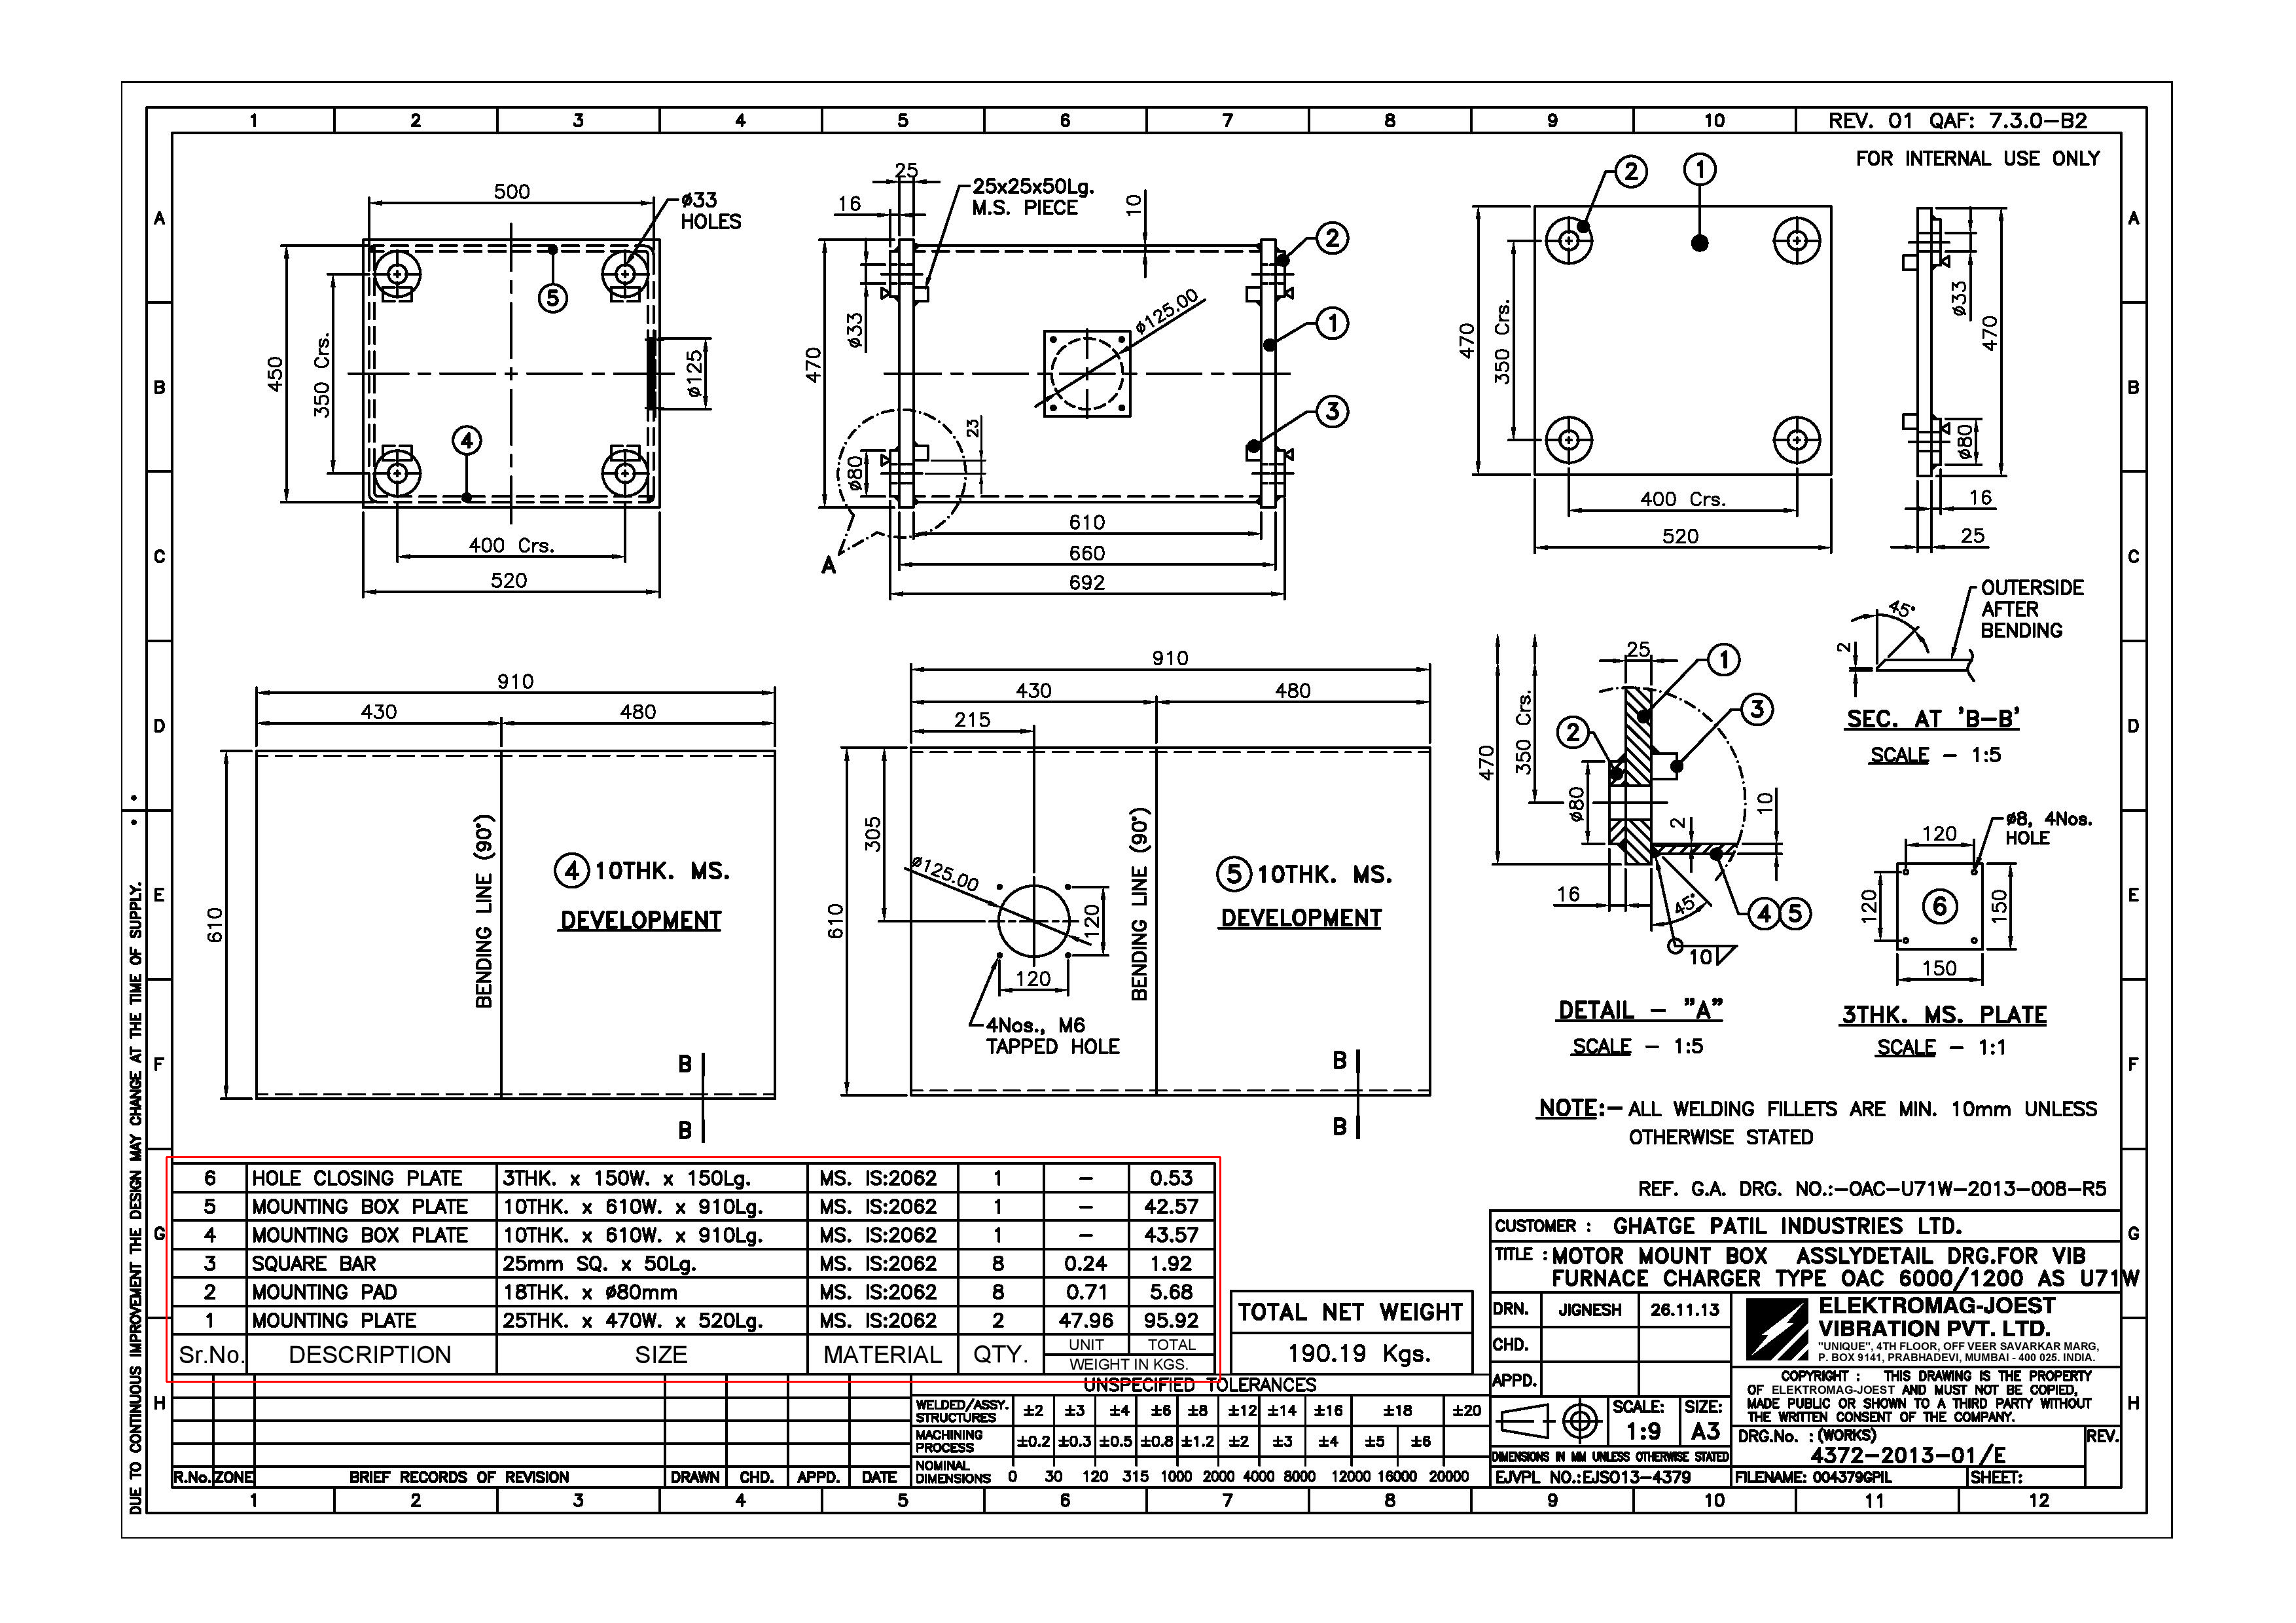

In [13]:
i = 1002
image_path = merged_drg_data.values[i,0]
print(image_path)
x = cv2.imread(image_path)
x_min = int(merged_drg_data.values[i,2])
y_min = int(merged_drg_data.values[i,3])
x_max = x_min + int(merged_drg_data.values[i,4])
y_max = y_min + int(merged_drg_data.values[i,5])

cv2.rectangle(x, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

cv2.imwrite("/Users/subrata/workstation/jupyterFiles/yolo_data_file/output.jpg", x)

x_pil = Image.fromarray(x)
display(x_pil)

In [41]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 921.9/921.9 kB 4.2 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip available: 22.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [14]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # Load pretrained model


In [17]:
import ultralytics
print(ultralytics.__version__)


8.3.80


In [19]:
print(model.model)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

In [19]:
# Define the function to convert and save YOLO format

def convert_to_yolo_format(df, save_path):
    os.makedirs(save_path, exist_ok=True)
    
    for _, row in df.iterrows():
        img_path = row["i_path"]
        image_name = os.path.basename(img_path)
        label_file = os.path.splitext(image_name)[0] + ".txt"

        # Extract bbox information
        x, y, width, height = row["x"], row["y"], row["width"], row["height"]
        img_wd, img_ht = row["img_wd"], row["img_ht"]
        obj_class = row["obj_class"]
        
        # Convert to YOLO format (normalized)
        x_center = (x + width / 2) / img_wd
        y_center = (y + height / 2) / img_ht
        norm_width = width / img_wd
        norm_height = height / img_ht
        
        # Ensure values are in [0, 1] range
        yolo_data = f"{obj_class} {x_center:.6f} {y_center:.6f} {norm_width:.6f} {norm_height:.6f}\n"
        
        # Save to label file
        with open(os.path.join(save_path, label_file), "a") as f:
            f.write(yolo_data)
        
# Convert and save annotations
convert_to_yolo_format(merged_drg_data, "/Users/subrata/workstation/jupyterFiles/yolo_data_file/all_labels")

print("YOLO annotations saved in 'all_labels' directory.")

YOLO annotations saved in 'all_labels' directory.


In [20]:
# Make all drawings directory named "all_images"

for i in range(len(merged_drg_data)):

    image_path = merged_drg_data.values[i,0]
    image_id = merged_drg_data.values[i,1].split(".")[0]
    x = cv2.imread(image_path)

    # Define output filename dynamically
    output_filename = f"/Users/subrata/workstation/jupyterFiles/yolo_data_file/all_images/{image_id}.jpg"

    # Save image
    cv2.imwrite(output_filename, x)



In [21]:
from sklearn.model_selection import train_test_split
import shutil

# Define paths
image_dir = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/all_images"
label_dir = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/all_labels"
train_img_dir = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/images/train"
val_img_dir = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/images/val"
train_label_dir = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/labels/train"
val_label_dir = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/labels/val"

# Create directories
for path in [train_img_dir, val_img_dir, train_label_dir, val_label_dir]:
    os.makedirs(path, exist_ok=True)

# Load image paths
image_paths = merged_drg_data["i_path"].tolist()

# Split data
train_images, val_images = train_test_split(image_paths, test_size=0.2, random_state=42)

# Move images and labels
def move_files(image_list, img_dest, label_dest):
    for img_path in image_list:
        img_name = os.path.basename(img_path)
        label_name = os.path.splitext(img_name)[0] + ".txt"
        
        # Move image
        shutil.copy(img_path, os.path.join(img_dest, img_name))
        
        # Move label file
        if os.path.exists(os.path.join(label_dir, label_name)):
            shutil.copy(os.path.join(label_dir, label_name), os.path.join(label_dest, label_name))

move_files(train_images, train_img_dir, train_label_dir)
move_files(val_images, val_img_dir, val_label_dir)

print("Data successfully split into train and validation sets.")

Data successfully split into train and validation sets.


In [69]:
print(train_img_dir)

/Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/images/train


In [22]:
# YOLOv8 requires a YAML configuration file specifying dataset paths
# Creating data.yaml file for feeding the training module

yaml_content = """train: /Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/images/train
val: /Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/images/val

nc: 2
names: ["n_bom", "bom"]
"""

with open("/Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/data.yaml", "w") as file:
    file.write(yaml_content)

print("data.yaml created successfully!")


data.yaml created successfully!


In [24]:
# Fixing Zero Bounding Box Cases

# If dataset includes images where the 'class' is absent, ensure:

# Delete empty label files (i.e., label files that only contain zeros).
# Do not include images with no objects in the labels folder.

# Since we already have such cases, we need to clean them up :

label_dir = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/labels/train"  # Adjust path as needed

# Iterate through all label files
for label_file in os.listdir(label_dir):
    label_path = os.path.join(label_dir, label_file)
    
    with open(label_path, "r") as f:
        lines = f.readlines()
    
    # If the label file is empty or contains invalid (zero) data, delete it
    if not lines or all(line.strip() == "0 0 0 0 0" for line in lines):
        os.remove(label_path)
        print(f"Deleted empty label file: {label_file}")

print("Cleanup complete!")

Cleanup complete!


In [28]:
ls /Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/labels/train


004379GPIL-Model-1-page-001.txt
004379GPIL-Model-10-page-001.txt
004379GPIL-Model-11-page-001.txt
004379GPIL-Model-14-page-001.txt
004379GPIL-Model-15-page-001.txt
004379GPIL-Model-16-page-001.txt
004379GPIL-Model-17-page-001.txt
004379GPIL-Model-19-page-001.txt
004379GPIL-Model-2-page-001.txt
004379GPIL-Model-20-page-001.txt
004379GPIL-Model-21-page-001.txt
004379GPIL-Model-3-page-001.txt
004379GPIL-Model-4-page-001.txt
004379GPIL-Model-6-page-001.txt
004379GPIL-Model-7-page-001.txt
004379GPIL-Model-8-page-001.txt
004379GPIL-Model-9-page-001.txt
004394MMPL-R1-Model-2.txt
004394MMPL-R1-Model-3.txt
004394MMPL-R1-Model-4.txt
006110BSBKEPL-Model-1.txt
006110BSBKEPL-Model-10.txt
006110BSBKEPL-Model-12.txt
006110BSBKEPL-Model-13.txt
006110BSBKEPL-Model-14.txt
006110BSBKEPL-Model-2.txt
006110BSBKEPL-Model-3.txt
006110BSBKEPL-Model-4.txt
006110BSBKEPL-Model-5.txt
006110BSBKEPL-Model-6.txt
006110BSBKEPL-Model-7.txt
006110BSBKEPL-Model-8.txt
006110BSBKEPL-Model-9.txt
007016SBIPL2-Model-1.txt
00

In [29]:

# Train the model
model.train(
    data="/Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/data.yaml", 
    epochs=10, 
    imgsz=640, 
    batch=8, 
    workers=2, 
    device="cpu"  # Since CUDA is not available
)

print("Training completed!")

New https://pypi.org/project/ultralytics/8.3.81 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.80 🚀 Python-3.9.15 torch-1.13.1 CPU (Apple M1)
WARNING ⚠️ Upgrade to torch>=2.0.0 for deterministic training.
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/data.yaml, epochs=10, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=cpu, workers=2, project=None, name=train9, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False

train: Scanning /Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/labels/train... 1122 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1122/1122 [00:00<00:00, 4855.76it/s]

train: New cache created: /Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/labels/train.cache



val: Scanning /Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/labels/val... 281 images, 0 backgrounds, 0 corrupt: 100%|██████████| 281/281 [00:00<00:00, 5006.31it/s]

val: New cache created: /Users/subrata/workstation/jupyterFiles/yolo_data_file/yolov8_dir/labels/val.cache
Plotting labels to runs/detect/train9/labels.jpg... 


...

      10/10         0G     0.3395     0.3911     0.8252          2        640: 100%|██████████| 141/141 [05:29<00:00,  2.34s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:51<00:00,  2.86s/it]

                   all        281        281       0.99        0.5      0.497      0.474



10 epochs completed in 1.020 hours.
Optimizer stripped from runs/detect/train9/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train9/weights/best.pt, 6.2MB

Validating runs/detect/train9/weights/best.pt...
Ultralytics 8.3.80 🚀 Python-3.9.15 torch-1.13.1 CPU (Apple M1)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:50<00:00,  2.79s/it]


                   all        281        281       0.99        0.5      0.496      0.477
                 n_bom         39         39          1          0          0          0
                   bom        242        242       0.98          1      0.993      0.953
Speed: 0.5ms preprocess, 135.7ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to runs/detect/train9
Training completed!


In [87]:
# Load the trained YOLOv8 model
model = YOLO("runs/detect/train9/weights/best.pt")

# Path to your test image
#test_image = "/Users/subrata/workstation/jupyterFiles/testdrg/SM-MFD-5KW-003-23.jpg" 
#test_image = "/Users/subrata/workstation/jupyterFiles/testdrg/8992-18-OAC-02-04-Model-page-001.jpg"  
test_image = "/Users/subrata/workstation/jupyterFiles/testdrg/EMM1-15-RC105-2-Model-page-001.jpg"

# Run inference
results = model(test_image, save=True, conf=0.5)
x1 = 0
x2 = 0
y1 = 0
y2 = 0
# Load the image using OpenCV

image = cv2.imread(test_image)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

# Process detection results
for result in results:
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])  # Bounding box coordinates
        class_id = int(box.cls[0])  # Class index
        confidence = float(box.conf[0])  # Confidence score

        # Crop the detected object
        cropped_obj = image[y1:y2, x1:x2]
        
        # Define box color (green for visibility)
        color = (0, 255, 0)  # RGB (Green)

        # Draw the bounding box
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 3)
        """
        # Display class name and confidence
        label = f"{model.names[class_id]} {confidence:.2f}"
        cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        """
# Show the result image
if x1 == 0:
    print("There is no bom")
else:
    x_pil = Image.fromarray(image)
    display(x_pil)



image 1/1 /Users/subrata/workstation/jupyterFiles/testdrg/EMM1-15-RC105-2-Model-page-001.jpg: 480x640 (no detections), 72.5ms
Speed: 7.4ms preprocess, 72.5ms inference, 5.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs/detect/predict56
There is no bom


In [27]:
## Extracting BOM from the test drawings with .jpg files from the trained model :

# Load the trained YOLOv8 model
model = YOLO("runs/detect/train9/weights/best.pt")

# Path to test folder (containing test images)

test_folder = "/Users/subrata/workstation/jupyterFiles/testdrg/"

output_folder = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_3/"  # Folder to save cropped images
os.makedirs(output_folder, exist_ok=True)  # Create folder if not exists

# List of images where 'bom' was not detected
no_bom_drgs = []

# Process each image in the test folder
for filename in os.listdir(test_folder):
    if filename.lower().endswith((".jpg", ".jpeg", ".png")):  # Check for image files
        test_image = os.path.join(test_folder, filename)

        # Run inference
        results = model(test_image, conf=0.5)
        x1 = 0
        y1 = 0
        x2 = 0
        y2 = 0
        crop_count = 0

        # Load the image using OpenCV
        image = cv2.imread(test_image)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

        # Extract filename (without extension)
        image_name = os.path.splitext(filename)[0]

        # Process detection results
        for result in results:
            for box in result.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])  # Bounding box coordinates
                class_id = int(box.cls[0])  # Class index
                confidence = float(box.conf[0])  # Confidence score

                # Crop the detected object
                cropped_obj = image[y1:(y2+10), x1:(x2+10)]

                # Save the cropped image
                cropped_filename_original = f"{output_folder}/{image_name}_crop_{crop_count}.jpg"
                
                cropped_filename = re.sub(r'_crop_\d+', '', cropped_filename_original)

                cv2.imwrite(cropped_filename, cv2.cvtColor(cropped_obj, cv2.COLOR_RGB2BGR))  # Convert RGB to BGR for saving
                crop_count += 1

        # If no 'bom' is detected, add the image to the list
        if x1 == 0:
            no_bom_drgs.append(filename)
            print(f"No 'bom' detected in {filename}.")

# Save the list of 'no bom' images to a text file
no_bom_file = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_no_bom.txt"
with open(no_bom_file, "w") as f:
    for img in no_bom_drgs:
        f.write(img + "\n")

print(f"\n📂 List of 'no bom' images saved to {no_bom_file}")
print(f"📂 Cropped images saved in {output_folder}")






image 1/1 /Users/subrata/workstation/jupyterFiles/testdrg/0085-16-SWZ-00-00 R2-Model-page-001.jpg: 480x640 1 bom, 48.5ms
Speed: 2.0ms preprocess, 48.5ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /Users/subrata/workstation/jupyterFiles/testdrg/1789073R0_MAIN_FRAME_ASSY_1 (SHT.1)-page-001.jpg: 480x640 (no detections), 52.0ms
Speed: 4.7ms preprocess, 52.0ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)
No 'bom' detected in 1789073R0_MAIN_FRAME_ASSY_1 (SHT.1)-page-001.jpg.

image 1/1 /Users/subrata/workstation/jupyterFiles/testdrg/1794039R1 (1 OF 4)_TRIPPER FRAME (FRONT PART)-page-001.jpg: 480x640 (no detections), 54.5ms
Speed: 4.0ms preprocess, 54.5ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)
No 'bom' detected in 1794039R1 (1 OF 4)_TRIPPER FRAME (FRONT PART)-page-001.jpg.

image 1/1 /Users/subrata/workstation/jupyterFiles/testdrg/1789073R0_MAIN_FRAME_ASSY_1 (SHT.2)-page-001.jpg: 480x640 1 bom, 47.7ms
Speed: 4.1ms

In [33]:
## Extracting BOM from the test drawings with .pdf files from the trained model :

## Load the trained YOLOv8 model
model = YOLO("runs/detect/train9/weights/best.pt")

# Path to test folder (containing test PDFs)
test_folder = "/Users/subrata/workstation/jupyterFiles/testdrg_1/"
output_folder = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_4/"  # Folder to save cropped images
os.makedirs(output_folder, exist_ok=True)  # Create folder if not exists

# List of PDFs where 'bom' was not detected
no_bom_drgs = []

# Process each PDF in the test folder
for filename in os.listdir(test_folder):
    if filename.lower().endswith(".pdf"):  # Check for PDF files
        pdf_path = os.path.join(test_folder, filename)

        # Convert PDF to images
        images = convert_from_path(pdf_path, dpi=300)  # Higher DPI for better OCR and detection

        pdf_has_bom = False  # Flag to track if BOM is detected in any page

        # Process each page
        for page_num, image in enumerate(images):
            # Convert PIL image to OpenCV format
            image_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

            # Run YOLO inference
            results = model(image_cv, conf=0.5)

            x1, y1, x2, y2 = 0, 0, 0, 0
            crop_count = 0

            # Process detection results
            for result in results:
                for box in result.boxes:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])  # Bounding box coordinates
                    class_id = int(box.cls[0])  # Class index
                    confidence = float(box.conf[0])  # Confidence score

                    # Crop the detected object
                    cropped_obj = image_cv[y1:(y2+10), x1:(x2+10)]

                    # Save the cropped image
                    cropped_filename = f"{output_folder}/{os.path.splitext(filename)[0]}_crop_{crop_count}.jpg"
                    cv2.imwrite(cropped_filename, cropped_obj)  # Save as BGR format
                    crop_count += 1
                    pdf_has_bom = True  # Mark that BOM was found

        # If no BOM was detected in any page, add to the list
        if not pdf_has_bom:
            no_bom_drgs.append(filename)
            print(f"No 'bom' detected in {filename}.")

# Save the list of PDFs with no BOM detected
no_bom_file = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_no_bom_4.txt"
with open(no_bom_file, "w") as f:
    for pdf in no_bom_drgs:
        f.write(pdf + "\n")

print(f"\n📂 List of 'no bom' PDFs saved to {no_bom_file}")
print(f"📂 Cropped images saved in {output_folder}")



0: 480x640 1 bom, 69.6ms
Speed: 5.3ms preprocess, 69.6ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 66.0ms
Speed: 4.4ms preprocess, 66.0ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)
No 'bom' detected in 1789074R0_MAIN_FRAME_ASSY_2 (SHT.1).pdf.

0: 480x640 (no detections), 64.9ms
Speed: 5.1ms preprocess, 64.9ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)
No 'bom' detected in 1-JM03-VD00-1-0002_BW-1600_12°_90Lbs).pdf.

0: 480x640 1 bom, 65.0ms
Speed: 4.5ms preprocess, 65.0ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 63.1ms
Speed: 3.4ms preprocess, 63.1ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)
No 'bom' detected in 1794039R1 (4 OF 4)_TRIPPER FRAME (FRONT PART).pdf.

0: 480x640 (no detections), 89.7ms
Speed: 16.8ms preprocess, 89.7ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)
No 'bom' detected in 17

In [21]:
import pdfplumber

# Path to your PDF file
pdf_path = "/path/to/your/file.pdf"

# Path to save the extracted Excel file
output_excel = "/path/to/output.xlsx"

# List to store table data
all_tables = []

# Open the PDF
with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        tables = page.extract_tables()  # Extract tables from the page
        for table in tables:
            df = pd.DataFrame(table)  # Convert table to DataFrame
            all_tables.append(df)

# Save each table in a separate sheet in Excel
with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    for i, df in enumerate(all_tables):
        df.to_excel(writer, sheet_name=f"Table_{i+1}", index=False, header=False)

print(f"✅ Extraction complete! Data saved to: {output_excel}")

FileNotFoundError: [Errno 2] No such file or directory: '/path/to/your/file.pdf'

In [95]:
import pytesseract

# Path to the folder containing images
image_folder = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom/one/"
output_excel = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/extracted_bom_data.xlsx"

# List to store extracted tables
tables_list = []

# Process each image in the folder
for filename in sorted(os.listdir(image_folder)):
    if filename.lower().endswith((".jpg", ".jpeg", ".png")):
        image_path = os.path.join(image_folder, filename)

        # Read image using OpenCV
        image = cv2.imread(image_path)

        # Convert to grayscale for better OCR
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Apply thresholding to clean the image (helps OCR)
        _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Use Tesseract OCR to extract text
        extracted_text = pytesseract.image_to_string(thresh, config="--psm 6")

        # Convert extracted text into a structured format
        table_data = [line.split() for line in extracted_text.split("\n") if line.strip()]
        df = pd.DataFrame(table_data)  # Convert to Pandas DataFrame

        # Store the extracted table
        tables_list.append((filename, df))

# Save tables to an Excel file
with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    for filename, df in tables_list:
        df.to_excel(writer, sheet_name=filename[:31], index=False, header=False)

print(f"✅ Extraction complete! Data saved to {output_excel}")


✅ Extraction complete! Data saved to /Users/subrata/workstation/jupyterFiles/yolo_data_file/extracted_bom_data.xlsx


In [102]:
## Find out all individual boxes for subsequent text extraction :

def all_boxes(pred_bom_id):
    
    boxes_list = []
    pred_bom = cv2.imread(pred_bom_id)
    pred_bom_clr = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)

    ##thresholding the image to a binary image
    thresh,img_bin = cv2.threshold(pred_bom_clr,0,255,cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    #inverting the image 
    img_bin_invert = 255-img_bin

    img_pil = Image.fromarray(img_bin_invert)
        
    display(img_pil) 
      
    # Length(width) of kernel as 100th of total width
    kernel_len = pred_bom_clr.shape[1]//100

    # Defining a vertical kernel to detect all vertical lines of image 
    ver_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, kernel_len))

    # Defining a horizontal kernel to detect all horizontal lines of image
    hor_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_len, 1))

    #Use vertical kernel to detect and save the vertical lines in a jpg
    image_1 = cv2.erode(img_bin_invert, ver_kernel, iterations=3)
    vertical_lines = cv2.dilate(image_1, ver_kernel, iterations=3)

    #Use horizontal kernel to detect and save the horizontal lines in a jpg
    image_2 = cv2.erode(img_bin_invert, hor_kernel, iterations=3)
    horizontal_lines = cv2.dilate(image_2, hor_kernel, iterations=3)

    # Combine horizontal and vertical lines in a new third image, with both having same weight.
    img_vh = cv2.addWeighted(vertical_lines, 0.5, horizontal_lines, 0.5, 0.0)

    # A kernel of 2x2
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    # print('Final kernel = ', kernel)

    img_vh_d = cv2.dilate(img_vh, kernel, iterations=2)

    img_vh_d_pil = Image.fromarray(img_vh_d)
        
    display(img_vh_d_pil)
        
    # Defining the cell boxes

    contours, hierarchy = cv2.findContours(img_vh_d, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    boxes = np.zeros((len(contours), 4))

    for i in range(len(contours)):
    
        cnt = contours[i]
        x, y, w, h = cv2.boundingRect(cnt)
        boxes[i, 0] = x
        boxes[i, 1] = y
        boxes[i, 2] = w
        boxes[i, 3] = h

    # print(len(boxes))
        
    boxes_list.append(boxes)
    
    return boxes_list      ## ## in format x, y, w, h


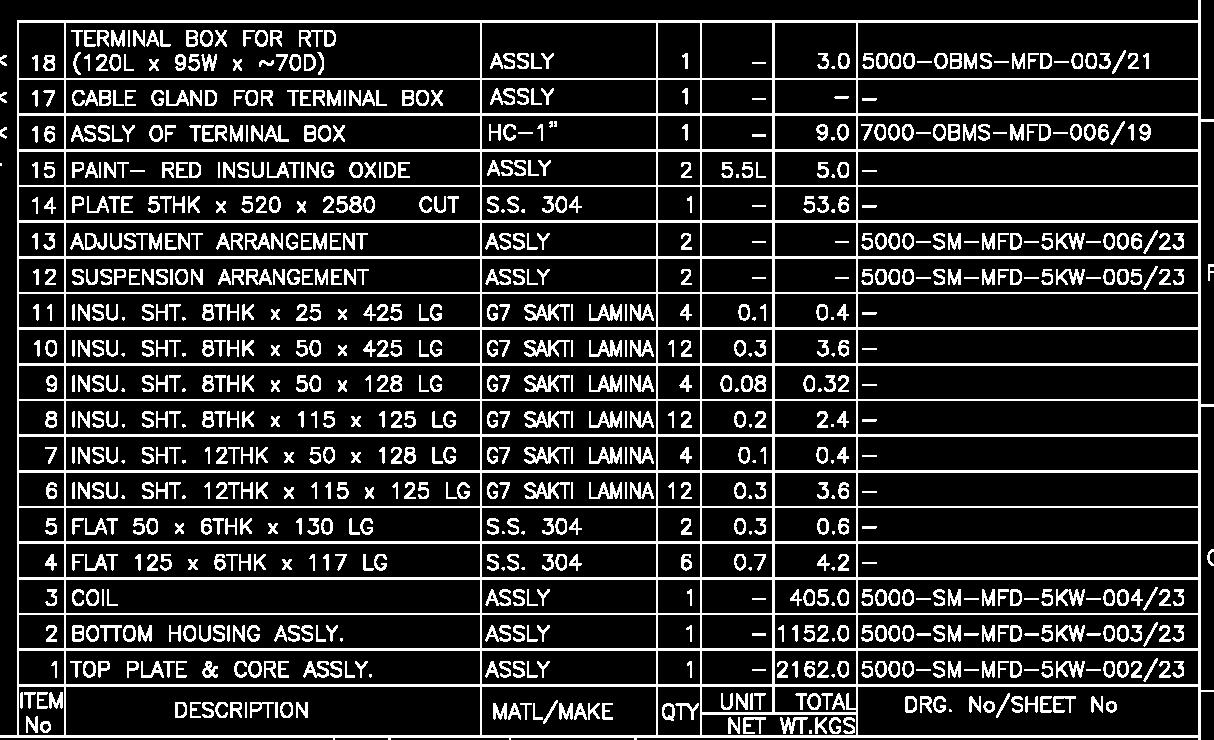

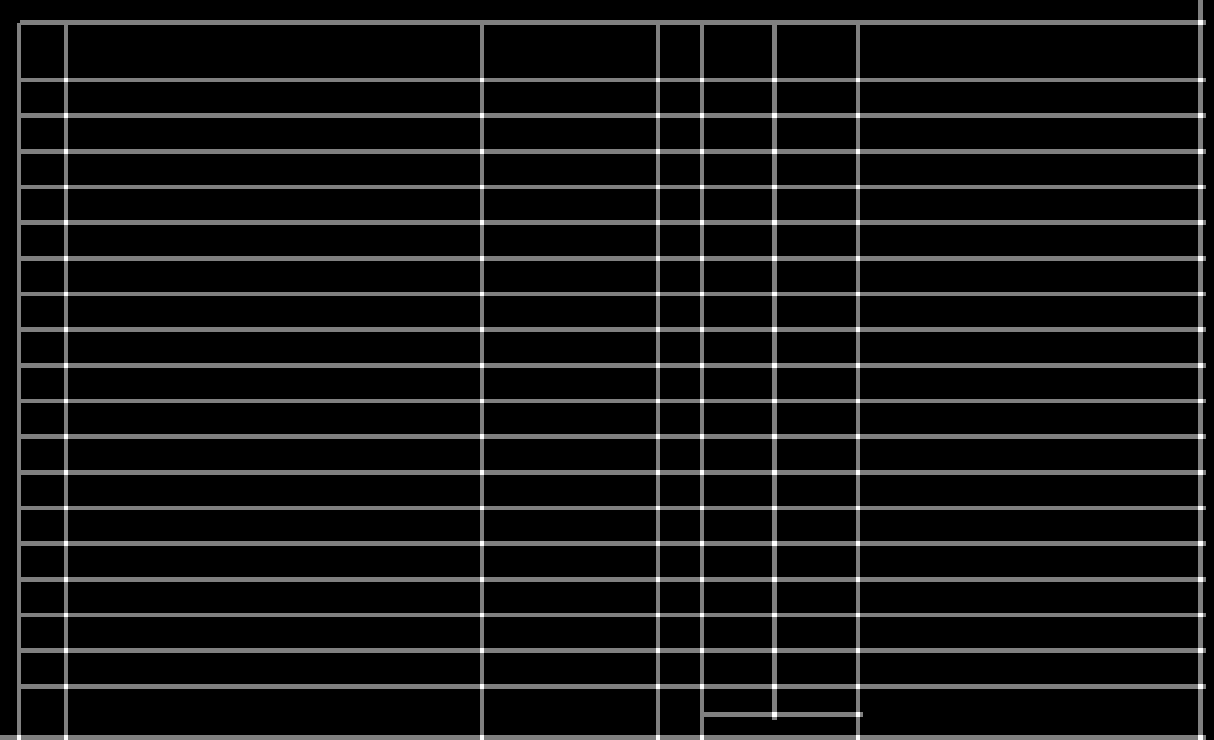

[array([[          0,           0,        1206,         740],
        [        703,         716,         154,          20],
        [        859,         688,         340,          48],
        [        776,         688,          81,          25],
        [        703,         688,          70,          25],
        [        659,         688,          42,          48],
        [        483,         688,         174,          48],
        [         67,         688,         414,          48],
        [         20,         688,          45,          48],
        [        859,         652,         340,          33],
        [        776,         652,          81,          33],
        [        703,         652,          70,          33],
        [        659,         652,          42,          33],
        [        483,         652,         174,          33],
        [         67,         652,         414,          33],
        [         20,         652,          45,          33],
        

In [103]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom/SM-MFD-5KW-001-23_crop_0.jpg"
all_boxes(pred_bom_id)

In [81]:
# Train the model on CPU
model.train(
    # data="dataset/data.yaml",  # Path to dataset
    data="dataset/data.yaml",
    epochs=50,                 # Number of epochs
    imgsz=640,                 # Image size
    batch=8,                    # Reduce batch size for CPU training
    workers=2,                 # Reduce workers for CPU
    device="cpu"               # Force training on CPU
)

print("Training completed on CPU!")

New https://pypi.org/project/ultralytics/8.3.81 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.80 🚀 Python-3.9.15 torch-1.13.1 CPU (Apple M1)
WARNING ⚠️ Upgrade to torch>=2.0.0 for deterministic training.
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=dataset/data.yaml, epochs=50, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=cpu, workers=2, project=None, name=train5, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, em

RuntimeError: Dataset 'dataset/data.yaml' error ❌ 'dataset/data.yaml' does not exist

In [12]:
def single_image_info(lines):
    
    ## lines will be a dataframe like, for i in range(num_images), lines = r_new_data[i*5:(i+1)*5]
    
    pic_path = lines.iat[0, 0]
    img_width = lines.iat[0, 7].astype(np.float32)
    img_height = lines.iat[0, 8].astype(np.float32)
    
    boxes = []
    labels = []
    for i in range(len(lines)):
        
        label = lines['obj_class'][i]
        x_cen, y_cen, wide, high = float(lines.iat[i,2]+lines.iat[i,4]*0.5), float(lines.iat[i,3]+lines.iat[i,5]*0.5), float(lines.iat[i,4]), float(lines.iat[i,5])
        boxes.append([x_cen, y_cen, wide, high])
        labels.append(label)
        
    boxes = np.asarray(boxes, np.float32)
    labels = np.asarray(labels, np.float32)
    
    return pic_path, boxes, labels, img_width, img_height  ## boxes are in format xcen, ycen, width, height


In [13]:
## Creating the complete data set :

all_image_line = []
limit_lower = 0
limit_upper = 0

for i in range(len(merged_drg_data)):

    image_line = []
    
    img = merged_drg_data['img_id'][limit_upper]
    kount = merged_drg_data['img_id'].value_counts()[img]    ## this gives no. of same images with region data of multiple categories
       
    limit_lower = limit_upper
    limit_upper = limit_lower + kount
    
    lines = merged_drg_data[limit_lower:limit_upper].reset_index(drop=True)
    """
    print('===================', i)
    print(img)
    print(limit_lower)
    print(limit_upper)
    """
    
    pic_path, boxes, labels, img_width, img_height = single_image_info(lines)
                                    
    image_line.append(pic_path)                  ## pic_path = path of the image
    image_line.append(boxes)                     ## boxes are in format x_cen, y_cen, width, height
    image_line.append(labels)                    ## labels are either 1 or 0
    image_line.append(img_width)
    image_line.append(img_height)
    all_image_line.append(image_line)
    
print(len(all_image_line))
print(all_image_line[1428])   ##  boxes are in format xcen, ycen, width, height

1429
['/Users/subrata/workstation/jupyterFiles/yolo_data_file/drg_test_9/10834-2-20-SWZ-04-02-Model-page-001.jpg', array([[1396.5,  909.5,  517. ,   71. ]], dtype=float32), array([1.], dtype=float32), 1754.0, 1240.0]


In [14]:
# Train and Test split

data_train_val, data_test = train_test_split(all_image_line, train_size = 0.9 , shuffle = True)
data_train, data_val = train_test_split(data_train_val, train_size = 0.80 , shuffle = True)

num_all_bbox = len(all_image_line) * len(all_image_line[0][2])
num_bb_train = len(data_train) * len(data_train[0][2])
num_bb_val = len(data_val) * len(data_val[0][2])
num_bb_test = len(data_test) * len(data_test[0][2])
print(num_all_bbox, num_bb_train, num_bb_val, num_bb_test)

1429 1028 258 143


In [15]:
y_true = np.zeros((1,5), np.float32)
y_true.shape

(1, 5)

In [31]:
image_index = []
image_resized = []
image_y_true = []

for i in range(len(data_train)):

    y_true = np.zeros((5), np.float32)
    img_resized = np.zeros((target_size[0], target_size[1]), np.float32)

    y_true[0] = data_train[i][2][0]
    y_true[1] = data_train[i][1][0][0] / data_train[i][3]
    y_true[2] = data_train[i][1][0][1] / data_train[i][4]
    y_true[3] = data_train[i][1][0][2] / data_train[i][3]
    y_true[4] = data_train[i][1][0][3] / data_train[i][4]

    image_y_true.append(y_true)

    bw_img = cv2.imread(data_train[i][0], cv2.IMREAD_GRAYSCALE)
    # img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(bw_img,(target_size[0], target_size[1]), interpolation=cv2.INTER_CUBIC)
    img_resized = img_resized / 255.0
    img_resized = img_resized.reshape((500, 700, 1))

    image_resized.append(img_resized)

X_train = np.array(image_resized).astype(np.float32)
Y_train = np.array(image_y_true).astype(np.float32)   

In [32]:
print(X_train.shape)
print(Y_train.shape)

(1028, 500, 700, 1)
(1028, 5)


In [34]:
image_index = []
image_resized = []
image_y_true = []

for i in range(len(data_val)):

    y_true = np.zeros((5), np.float32)
    img_resized = np.zeros((target_size[0], target_size[1]), np.float32)
    
    y_true[0] = data_val[i][2][0]
    y_true[1] = data_val[i][1][0][0] / data_val[i][3]
    y_true[2] = data_val[i][1][0][1] / data_val[i][4]
    y_true[3] = data_val[i][1][0][2] / data_val[i][3]
    y_true[4] = data_val[i][1][0][3] / data_val[i][4]

    image_y_true.append(y_true)

    bw_img = cv2.imread(data_val[i][0], cv2.IMREAD_GRAYSCALE)
    # img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(bw_img,(target_size[0], target_size[1]), interpolation=cv2.INTER_CUBIC)
    img_resized = img_resized / 255.0
    img_resized = img_resized.reshape((500,700,1))

    image_resized.append(img_resized)

X_val = np.array(image_resized).astype(np.float32)
Y_val = np.array(image_y_true).astype(np.float32)   

In [19]:
image_index = []
image_resized = []
image_y_true = []

for i in range(len(data_test)):

    y_true = np.zeros((1,5), np.float32)
    img_resized = np.zeros((target_size[0], target_size[1]), np.float32)

    y_true[0][0] = data_test[i][2][0]
    y_true[0][1] = data_test[i][1][0][0] / data_test[i][3]
    y_true[0][2] = data_test[i][1][0][1] / data_test[i][4]
    y_true[0][3] = data_test[i][1][0][2] / data_test[i][3]
    y_true[0][4] = data_test[i][1][0][3] / data_test[i][4]

    image_y_true.append(y_true)

    bw_img = cv2.imread(data_test[i][0], cv2.IMREAD_GRAYSCALE)
    # img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(bw_img,(target_size[0], target_size[1]), interpolation=cv2.INTER_CUBIC)
    img_resized = img_resized / 255.0
    img_resized = img_resized.reshape((500,700,1))

    image_resized.append(img_resized)

X_test = np.array(image_resized).astype(np.float32)
Y_test = np.array(image_y_true).astype(np.float32)   

In [35]:

def make_my_model_1():
# Define input layer
    inputs = Input(shape=(500, 700, 1))

    # Add first conv2D layer
    x = Conv2D(32, (3, 3), strides=1, padding='same')(inputs)
    # x = Conv2D(16, (5, 5), strides=1)(inputs)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)

    # Add second conv2D layer
    x = Conv2D(64, (3, 3), strides=2, padding='valid')(x)
    # x = Conv2D(32, (3, 3), strides=2)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Add third conv2D layer
    x = Conv2D(32, (3, 3), strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Add fourth conv2D layer
    x = Conv2D(128, (3, 3), strides=2, padding='valid')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(64, (3, 3), strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(128, (3, 3), strides=2, padding='valid')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    x = Conv2D(64, (3, 3), strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(32, (3, 3), strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)


    # Flatten and add fully connected layer
    x = Flatten()(x)
    y = Dense(1, activation='sigmoid', name='cls_output')(x)
    z = Dense(4, activation = 'linear', name='loc_output')(x)
    y_z = concatenate([y,z])
    # final = Reshape((1,5))(y_z)

    # Create model
    model = Model(inputs, y_z)

    return model



In [53]:
my_model_3= make_my_model_1()
print(my_model_3.summary())

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 500, 700, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_20 (Conv2D)             (None, 500, 700, 32  320         ['input_4[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization_20 (BatchN  (None, 500, 700, 32  128        ['conv2d_20[0][0]']              
 ormalization)                  )                                                           

In [48]:
def convert_to_corners(y_old):
    obj_class, x_center, y_center, width, height = tf.unstack(y_old, axis=1)
    # print(x_center, 'and', width)
    x_min = x_center - width / 2.
    y_min = y_center - height / 2.
    x_max = x_center + width / 2.
    y_max = y_center + height / 2.

    y_revised = tf.stack([obj_class, x_min, y_min, x_max, y_max], axis=1)

    return y_revised


In [44]:
convert_to_corners(Y_train[0])

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([1.        , 0.5932155 , 0.5288423 , 0.94840366, 0.76280755],
      dtype=float32)>

In [37]:
#calculate iou between target box and predicted box

def iou(y_true, y_pred):
    # Extracting coordinates from tensors

    y_true_rev = convert_to_corners(y_true)
    y_pred_rev = convert_to_corners(y_pred)

    # print(y_true_rev.shape)

    true_box = tf.squeeze(y_true_rev[..., 1:])
    pred_box = tf.squeeze(y_pred_rev[..., 1:])

    # print(true_box.shape)

    # Calculating intersection coordinates
    xi1 = tf.maximum(true_box[..., 0], pred_box[..., 0])
    yi1 = tf.maximum(true_box[..., 1], pred_box[..., 1])
    xi2 = tf.minimum(true_box[..., 0] + true_box[..., 2], pred_box[..., 0] + pred_box[..., 2])
    yi2 = tf.minimum(true_box[..., 1] + true_box[..., 3], pred_box[..., 1] + pred_box[..., 3])

    # Calculating intersection area
    inter_area = tf.maximum((xi2 - xi1), 0.0) * tf.maximum((yi2 - yi1), 0.0)

    # Calculating union area
    true_area = true_box[..., 2] * true_box[..., 3]
    pred_area = pred_box[..., 2] * pred_box[..., 3]
    union_area = true_area + pred_area - inter_area
    # print('union_area =', union_area)
    # Calculating IOU
    iou = inter_area / K.maximum(union_area, K.epsilon())
    
    return iou, union_area



In [ ]:
# class loss
gamma = 2
iou = iou(y_true, y_pred)

if y_true[..., :1] == 1:
    f_iou = 1-(1-iou) ** gamma
else:
    f_iou = (1-iou) ** gamma 
bce = tf.keras.losses.BinaryCrossentropy()
cls_loss = f_iou * bce(y_true[..., :1], y_pred[..., :1]).numpy()

In [44]:


def classification_loss(y_true, y_pred):
    # Extract the object label and bounding box coordinates
    y_true_cls = y_true[:, :, 0]
    y_pred_cls = y_pred[:, :, 0]

    # Calculate the intersection over union (IoU)
    x_true_min = y_true[:, :, 1]
    y_true_min = y_true[:, :, 2]
    w_true = y_true[:, :, 3]
    h_true = y_true[:, :, 4]
    x_pred_min = y_pred[:, :, 1]
    y_pred_min = y_pred[:, :, 2]
    w_pred = y_pred[:, :, 3]
    h_pred = y_pred[:, :, 4]
    xA = K.maximum(x_true_min, x_pred_min)
    yA = K.maximum(y_true_min, y_pred_min)
    xB = K.minimum(x_true_min + w_true, x_pred_min + w_pred)
    yB = K.minimum(y_true_min + h_true, y_pred_min + h_pred)
    interArea = K.maximum(0.0, xB - xA) * K.maximum(0.0, yB - yA)
    boxAArea = w_true * h_true
    boxBArea = w_pred * h_pred
    iou = interArea / (boxAArea + boxBArea - interArea)

    # Calculate the focal loss
    alpha = 0.25
    gamma = 2.0
    eps = K.epsilon()
    pt_1 = tf.where(K.equal(y_true_cls, 1), y_pred_cls, tf.ones_like(y_pred_cls))
    pt_0 = tf.where(K.equal(y_true_cls, 0), y_pred_cls, tf.zeros_like(y_pred_cls) + eps)
    pt_1 = K.clip(pt_1, eps, 1 - eps)
    pt_0 = K.clip(pt_0, eps, 1 - eps)
    loss = -K.mean(alpha * K.pow(1 - pt_1, gamma) * K.log(pt_1) \
                + (1 - alpha) * K.pow(pt_0, gamma) * K.log(1 - pt_0))

    # Apply the focal loss factor based on the IoU
    focal_factor = K.pow((1 - iou), gamma)
    loss = loss * focal_factor

    # Calculate the positive and negative examples counts
    num_positives = K.sum(y_true_cls)
    num_negatives = K.sum(1 - y_true_cls)

    # Balance the loss between positive and negative examples
    beta = num_negatives / (num_negatives + num_positives + eps)
    balanced_loss = beta * loss + (1 - beta) * K.mean(loss * y_true_cls)

    return balanced_loss

    



In [49]:
# localisation loss based on DIou
# https://arxiv.org/pdf/2011.05523.pdf#:~:text=The%20loss%20functions%20of%20object,box%20to%20locate%20target%20object.

def DIoU_loss(y_true, y_pred):
    
    true_class, x_true_cen, y_true_cen, width_true, height_true = tf.unstack(y_true, axis=1)
    pred_class, x_pred_cen, y_pred_cen, width_pred, height_pred = tf.unstack(y_pred, axis=1)

    diou, u_area = iou(y_true, y_pred)
    c_distance = K.pow(x_true_cen - x_pred_cen, 2) + K.pow(y_true_cen - y_pred_cen, 2)

    # Calculate DIoU loss
    # diou = intersection_area / K.maximum(union_area, K.epsilon())

    iou_distance = diou - K.clip((c_distance / u_area), 0, 1)
    diou_loss = 1 - iou_distance
    return diou_loss


In [51]:
from keras.callbacks import LearningRateScheduler

def step_decay(epoch, initial_lr, drop, epochs_drop):
    lr = initial_lr * (drop ** (epoch // epochs_drop))
    return lr

#from tensorflow.keras.callbacks import LearningRateScheduler

initial_learning_rate = 0.0001
lr_decay = 0.1
epochs_drop = 15

# Define the learning rate schedule using the step decay function
lr_scheduler = LearningRateScheduler(lambda epoch: step_decay(epoch, initial_learning_rate, lr_decay, epochs_drop))


In [47]:
from tensorflow.keras.optimizers import SGD

opt = SGD(learning_rate=0.001)

my_model_1.compile(optimizer=opt, loss={'cls_output': classification_loss, 'loc_output': DIoU_loss})


In [48]:
history = my_model_1.fit(X_train,Y_train, epochs=epoch, batch_size = 16, validation_data=(X_val,Y_val), callbacks=[lr_scheduler])


Epoch 1/50


ValueError: in user code:

    File "/Users/subrata/.pyenv/versions/3.9.15/lib/python3.9/site-packages/keras/engine/training.py", line 1249, in train_function  *
        return step_function(self, iterator)
    File "/Users/subrata/.pyenv/versions/3.9.15/lib/python3.9/site-packages/keras/engine/training.py", line 1233, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/Users/subrata/.pyenv/versions/3.9.15/lib/python3.9/site-packages/keras/engine/training.py", line 1222, in run_step  **
        outputs = model.train_step(data)
    File "/Users/subrata/.pyenv/versions/3.9.15/lib/python3.9/site-packages/keras/engine/training.py", line 1024, in train_step
        loss = self.compute_loss(x, y, y_pred, sample_weight)
    File "/Users/subrata/.pyenv/versions/3.9.15/lib/python3.9/site-packages/keras/engine/training.py", line 1082, in compute_loss
        return self.compiled_loss(
    File "/Users/subrata/.pyenv/versions/3.9.15/lib/python3.

In [60]:
def classification_loss(gamma=2.0):

    def binary_focal_loss(y_true, y_pred):
        # Extract the object label and bounding box coordinates
        y_true_cls = y_true[:, :, 0]
        y_pred_cls = y_pred[:, :, 0]

        # Calculate the intersection over union (IoU)
        x_true_min = y_true[:, :, 1]
        y_true_min = y_true[:, :, 2]
        w_true = y_true[:, :, 3]
        h_true = y_true[:, :, 4]
        x_pred_min = y_pred[:, :, 1]
        y_pred_min = y_pred[:, :, 2]
        w_pred = y_pred[:, :, 3]
        h_pred = y_pred[:, :, 4]
        xA = K.maximum(x_true_min, x_pred_min)
        yA = K.maximum(y_true_min, y_pred_min)
        xB = K.minimum(x_true_min + w_true, x_pred_min + w_pred)
        yB = K.minimum(y_true_min + h_true, y_pred_min + h_pred)
        interArea = K.maximum(0.0, xB - xA) * K.maximum(0.0, yB - yA)
        boxAArea = w_true * h_true
        boxBArea = w_pred * h_pred
        iou = interArea / (boxAArea + boxBArea - interArea)

        # Calculate the focal loss
        alpha = 0.25
        # gamma = gamma
        eps = K.epsilon()
        pt_1 = tf.where(K.equal(y_true_cls, 1), y_pred_cls, tf.ones_like(y_pred_cls))
        pt_0 = tf.where(K.equal(y_true_cls, 0), y_pred_cls, tf.zeros_like(y_pred_cls) + eps)
        pt_1 = K.clip(pt_1, eps, 1 - eps)
        pt_0 = K.clip(pt_0, eps, 1 - eps)
        loss = -K.mean(alpha * K.pow(1 - pt_1, gamma) * K.log(pt_1) \
                    + (1 - alpha) * K.pow(pt_0, gamma) * K.log(1 - pt_0))

        # Apply the focal loss factor based on the IoU
        focal_factor = K.pow((1 - iou), gamma)
        loss = loss * focal_factor

        # Calculate the positive and negative examples counts
        num_positives = K.sum(y_true_cls)
        num_negatives = K.sum(1 - y_true_cls)

        # Balance the loss between positive and negative examples
        beta = num_negatives / (num_negatives + num_positives + eps)
        balanced_loss = beta * loss + (1 - beta) * K.mean(loss * y_true_cls)

        return balanced_loss

    return binary_focal_loss

def loca_loss(factor=1.0):

    def DIoU_loss(y_true, y_pred):
        # Extract the bounding box coordinates for both true and predicted values
        x_true_min = y_true[:, :, 1]
        y_true_min = y_true[:, :, 2]
        w_true = y_true[:, :, 3]
        h_true = y_true[:, :, 4]
        x_pred_min = y_pred[:, :, 1]
        y_pred_min = y_pred[:, :, 2]
        w_pred = y_pred[:, :, 3]
        h_pred = y_pred[:, :, 4]

        # Calculate the coordinates of the diagonal (upper left and lower right) points 
        xA = K.maximum(x_true_min, x_pred_min)
        yA = K.maximum(y_true_min, y_pred_min)
        xB = K.minimum(x_true_min + w_true, x_pred_min + w_pred)
        yB = K.minimum(y_true_min + h_true, y_pred_min + h_pred)

        # Calculate intersection area and union area
        intersection_area = K.maximum(0.0, xB - xA) * K.maximum(0.0, yB - yA)
        true_box_area = w_true * h_true
        pred_box_area = w_pred * h_pred
        union_area = true_box_area + pred_box_area - intersection_area

        # Calculate the enclosed distance between two boxes' centroids
        c_true_x = x_true_min + w_true / 2
        c_true_y = y_true_min + h_true / 2
        c_pred_x = x_pred_min + w_pred / 2
        c_pred_y = y_pred_min + h_pred / 2
        c_distance = K.pow(c_true_x - c_pred_x, 2) + K.pow(c_true_y - c_pred_y, 2)

        # Calculate the minimum distance between each side of both boxes
        wA = x_true_min + w_true - x_true_min
        hA = y_true_min + h_true - y_true_min
        wB = x_pred_min + w_pred - x_pred_min
        hB = y_pred_min + h_pred - y_pred_min
        min_distance = K.minimum(wA, wB) * 0.5 + K.minimum(hA, hB) * 0.5

        # Calculate DIoU loss
        diou = intersection_area / union_area
        diou_distance = diou - K.clip((c_distance / union_area), 0, 1)
        diou_loss = (1 - diou_distance) * factor
        return diou_loss
    return DIoU_loss

def combined_loss(gamma=2.0, factor=1.0):

    def combined_loss_fixed(y_true, y_pred):
        
        # class_true, loc_true = y_true[:, :, :1], y_true[:, :, 1:]
        # class_pred, loc_pred = y_pred[:, :, :1], y_pred[:, :, 1:]
        
        # class_loss = classification_loss(gamma=gamma)(y_true, y_pred)
        loc_loss = loca_loss(factor=factor)(y_true, y_pred)
        # combo_loss = class_loss + loc_loss
        combo_loss = loc_loss

        return combo_loss

    return combined_loss_fixed



In [27]:
from tensorflow.keras.callbacks import Callback

class PrintIntermediateValues(Callback):
    
    def on_epoch_end(self, epoch, logs=None):
        # You can access any desired values from logs dictionary
        print("Epoch:", epoch)
        print("Loss:", logs['loss'])
        print("Validation Loss:", logs['val_loss'])
        print("x_true_min:", logs['x_true_min'])
        
# Create an instance of the callback
print_callback = PrintIntermediateValues()

opt = Adam(beta_1=0.9, beta_2=0.999, epsilon=1e-08)
my_model_1.compile(loss=DIoU_loss, optimizer=opt)
# Modify your training code to include the callback
history = my_model_1.fit(X_train,Y_train, epochs=5, batch_size = 16, 
                         validation_data=(X_val,Y_val), 
                         callbacks=[lr_scheduler, print_callback])


Epoch 1/5


2023-06-28 23:06:59.188516: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


65/65 [==============================] - ETA: 0s - loss: 1.0064Epoch: 0
Loss: 1.0063505172729492
Validation Loss: 1.0


KeyError: 'x_true_min'

In [26]:
epoch = 50
opt = Adam(beta_1=0.9, beta_2=0.999, epsilon=1e-08)
# my_model_1.compile(loss=combined_loss(gamma=2.0, factor=1.0), optimizer=opt)
my_model_1.compile(loss=DIoU_loss, optimizer=opt)
history = my_model_1.fit(X_train,Y_train, epochs=epoch, batch_size = 16, validation_data=(X_val,Y_val), callbacks=[lr_scheduler])


Epoch 1/50


2023-07-03 00:23:23.445950: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


65/65 [==============================] - 281s 4s/step - loss: 1.1648 - val_loss: 1.0489 - lr: 1.0000e-04
Epoch 2/50
65/65 [==============================] - 298s 5s/step - loss: 1.0046 - val_loss: 1.0088 - lr: 1.0000e-04
Epoch 3/50
65/65 [==============================] - 304s 5s/step - loss: 1.0016 - val_loss: 1.0021 - lr: 1.0000e-04
Epoch 4/50
65/65 [==============================] - 306s 5s/step - loss: 1.0009 - val_loss: 1.0010 - lr: 1.0000e-04
Epoch 5/50
65/65 [==============================] - 320s 5s/step - loss: 1.0006 - val_loss: 1.0009 - lr: 1.0000e-04
Epoch 6/50
65/65 [==============================] - 310s 5s/step - loss: 1.0004 - val_loss: 1.0009 - lr: 1.0000e-04
Epoch 7/50
65/65 [==============================] - 311s 5s/step - loss: 1.0003 - val_loss: 1.0006 - lr: 1.0000e-04
Epoch 8/50
65/65 [==============================] - 309s 5s/step - loss: 1.0002 - val_loss: 1.0004 - lr: 1.0000e-04
Epoch 9/50
65/65 [==============================] - 311s 5s/step - loss: 1.0002 - v

KeyboardInterrupt: 

In [29]:
epoch = 50
opt = Adam(beta_1=0.9, beta_2=0.999, epsilon=1e-08)
# my_model_1.compile(loss=combined_loss(gamma=2.0, factor=1.0), optimizer=opt)
my_model_2.compile(loss=DIoU_loss, optimizer=opt)
history = my_model_2.fit(X_train,Y_train, epochs=epoch, batch_size = 16, validation_data=(X_val,Y_val), callbacks=[lr_scheduler])


Epoch 1/50
65/65 [==============================] - 391s 6s/step - loss: 1.0700 - val_loss: 1.0030 - lr: 1.0000e-04
Epoch 2/50
65/65 [==============================] - 467s 7s/step - loss: 1.0025 - val_loss: 1.0012 - lr: 1.0000e-04
Epoch 3/50
65/65 [==============================] - 486s 7s/step - loss: 1.0014 - val_loss: 1.0002 - lr: 1.0000e-04
Epoch 4/50
65/65 [==============================] - 494s 8s/step - loss: 1.0009 - val_loss: 1.0001 - lr: 1.0000e-04
Epoch 5/50
65/65 [==============================] - 474s 7s/step - loss: 1.0006 - val_loss: 1.0001 - lr: 1.0000e-04
Epoch 6/50
65/65 [==============================] - 474s 7s/step - loss: 1.0004 - val_loss: 1.0001 - lr: 1.0000e-04
Epoch 7/50
65/65 [==============================] - 464s 7s/step - loss: 1.0003 - val_loss: 1.0001 - lr: 1.0000e-04
Epoch 8/50
65/65 [==============================] - 439s 7s/step - loss: 1.0001 - val_loss: 1.0002 - lr: 1.0000e-04
Epoch 9/50
65/65 [==============================] - 430s 7s/step - loss:

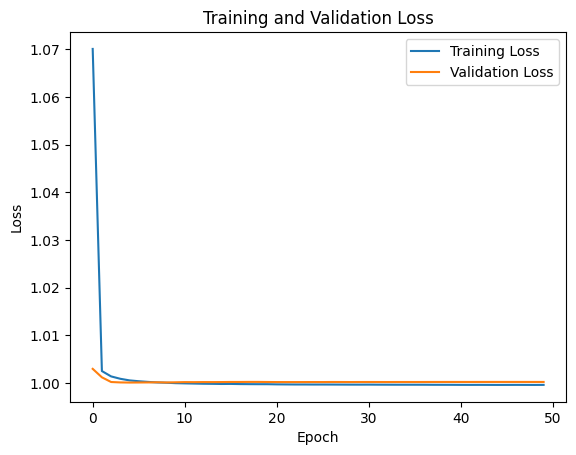

In [30]:
# Plot the training and validation loss over epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [54]:
epoch = 50
opt = Adam(beta_1=0.9, beta_2=0.999, epsilon=1e-08)
# my_model_1.compile(loss=combined_loss(gamma=2.0, factor=1.0), optimizer=opt)
my_model_3.compile(loss=DIoU_loss, optimizer=opt)
history = my_model_3.fit(X_train,Y_train, epochs=epoch, batch_size = 16, validation_data=(X_val,Y_val), callbacks=[lr_scheduler])


Epoch 1/50
65/65 [==============================] - 373s 6s/step - loss: 1.0269 - val_loss: 1.0068 - lr: 1.0000e-04
Epoch 2/50
65/65 [==============================] - 400s 6s/step - loss: 1.0021 - val_loss: 1.0014 - lr: 1.0000e-04
Epoch 3/50
65/65 [==============================] - 396s 6s/step - loss: 1.0010 - val_loss: 1.0003 - lr: 1.0000e-04
Epoch 4/50
65/65 [==============================] - 399s 6s/step - loss: 1.0006 - val_loss: 1.0006 - lr: 1.0000e-04
Epoch 5/50
65/65 [==============================] - 404s 6s/step - loss: 1.0003 - val_loss: 1.0003 - lr: 1.0000e-04
Epoch 6/50
65/65 [==============================] - 393s 6s/step - loss: 1.0002 - val_loss: 1.0002 - lr: 1.0000e-04
Epoch 7/50
65/65 [==============================] - 384s 6s/step - loss: 1.0001 - val_loss: 1.0002 - lr: 1.0000e-04
Epoch 8/50
65/65 [==============================] - 387s 6s/step - loss: 1.0001 - val_loss: 1.0003 - lr: 1.0000e-04
Epoch 9/50
65/65 [==============================] - 393s 6s/step - loss:

KeyboardInterrupt: 

In [34]:
y_true = tf.constant([[1., 10., 10., 50., 50.]])
y_pred = tf.constant([[1., 20., 20., 60., 60.]])
loss = DIoU_loss(y_true, y_pred)
print(loss)


tf.Tensor([0.7522124], shape=(1,), dtype=float32)


In [ ]:
import tensorflow.keras.backend as K

def diou_loss(y_true, y_pred):
    # Extract the coordinates from y_true and y_pred
    x_true, y_true, w_true, h_true = tf.unstack(y_true, axis=1)
    x_pred, y_pred, w_pred, h_pred = tf.unstack(y_pred, axis=1)

    # Convert to top-left and bottom-right corner coordinates
    x_true_tl = x_true - w_true / 2
    y_true_tl = y_true - h_true / 2
    x_true_br = x_true + w_true / 2
    y_true_br = y_true + h_true / 2

    x_pred_tl = x_pred - w_pred / 2
    y_pred_tl = y_pred - h_pred / 2
    x_pred_br = x_pred + w_pred / 2
    y_pred_br = y_pred + h_pred / 2

    # Calculate IoU
    intersection_xmin = K.maximum(x_true_tl, x_pred_tl)
    intersection_ymin = K.maximum(y_true_tl, y_pred_tl)
    intersection_xmax = K.minimum(x_true_br, x_pred_br)
    intersection_ymax = K.minimum(y_true_br, y_pred_br)
    intersection_width = K.maximum(intersection_xmax - intersection_xmin, 0)
    intersection_height = K.maximum(intersection_ymax - intersection_ymin, 0)
    intersection_area = intersection_width * intersection_height

    true_box_area = w_true * h_true
    pred_box_area = w_pred * h_pred
    union_area = true_box_area + pred_box_area - intersection_area

    iou_loss = -K.log((intersection_area + 1.0) / (union_area + 1.0))

    # Calculate Euclidean distance
    center_distance = K.sqrt(K.square(x_true - x_pred) + K.square(y_true - y_pred))

    # Calculate DIoU loss
    alpha = 1.0  # You can adjust the value of alpha as needed
    diou_loss = iou_loss - alpha * K.square(center_distance)

    return diou_loss


In [ ]:
import tensorflow.keras.backend as K

def diou_loss(y_true, y_pred):
    # Extract the coordinates from y_true and y_pred
    x_true, y_true, w_true, h_true = tf.unstack(y_true, axis=1)
    x_pred, y_pred, w_pred, h_pred = tf.unstack(y_pred, axis=1)

    # Convert to top-left and bottom-right corner coordinates
    x_true_tl = x_true - w_true / 2
    y_true_tl = y_true - h_true / 2
    x_true_br = x_true + w_true / 2
    y_true_br = y_true + h_true / 2

    x_pred_tl = x_pred - w_pred / 2
    y_pred_tl = y_pred - h_pred / 2
    x_pred_br = x_pred + w_pred / 2
    y_pred_br = y_pred + h_pred / 2

    # Calculate IoU
    intersection_xmin = K.maximum(x_true_tl, x_pred_tl)
    intersection_ymin = K.maximum(y_true_tl, y_pred_tl)
    intersection_xmax = K.minimum(x_true_br, x_pred_br)
    intersection_ymax = K.minimum(y_true_br, y_pred_br)
    intersection_width = K.maximum(intersection_xmax - intersection_xmin, 0)
    intersection_height = K.maximum(intersection_ymax - intersection_ymin, 0)
    intersection_area = intersection_width * intersection_height

    true_box_area = w_true * h_true
    pred_box_area = w_pred * h_pred
    union_area = true_box_area + pred_box_area - intersection_area

    iou_loss = -K.log((intersection_area + 1.0) / (union_area + 1.0))

    # Calculate Euclidean distance
    center_distance = K.sqrt(K.square(x_true - x_pred) + K.square(y_true - y_pred))

    # Calculate DIoU loss
    alpha = 1.0  # You can adjust the value of alpha as needed
    diou_loss = iou_loss - alpha * K.square(center_distance)

    return diou_loss


In [ ]:
import tensorflow.keras.backend as K

def diou_loss(y_true, y_pred):
    # Extract the coordinates from y_true and y_pred
    x_true, y_true, w_true, h_true = tf.unstack(y_true, axis=1)
    x_pred, y_pred, w_pred, h_pred = tf.unstack(y_pred, axis=1)

    # Convert to top-left and bottom-right corner coordinates
    x_true_tl = x_true - w_true / 2
    y_true_tl = y_true - h_true / 2
    x_true_br = x_true + w_true / 2
    y_true_br = y_true + h_true / 2

    x_pred_tl = x_pred - w_pred / 2
    y_pred_tl = y_pred - h_pred / 2
    x_pred_br = x_pred + w_pred / 2
    y_pred_br = y_pred + h_pred / 2

    # Calculate IoU
    intersection_xmin = K.maximum(x_true_tl, x_pred_tl)
    intersection_ymin = K.maximum(y_true_tl, y_pred_tl)
    intersection_xmax = K.minimum(x_true_br, x_pred_br)
    intersection_ymax = K.minimum(y_true_br, y_pred_br)
    intersection_width = K.maximum(intersection_xmax - intersection_xmin, 0)
    intersection_height = K.maximum(intersection_ymax - intersection_ymin, 0)
    intersection_area = intersection_width * intersection_height

    true_box_area = w_true * h_true
    pred_box_area = w_pred * h_pred
    union_area = true_box_area + pred_box_area - intersection_area

    iou_loss = -K.log((intersection_area + 1.0) / (union_area + 1.0))

    # Calculate Euclidean distance
    center_distance = K.sqrt(K.square(x_true - x_pred) + K.square(y_true - y_pred))

    # Calculate DIoU loss
    alpha = 1.0  # You can adjust the value of alpha as needed
    diou_loss = iou_loss - alpha * K.square(center_distance)

    return diou_loss


In [69]:
import tensorflow.keras.backend as K

def diou_loss(y_true, y_pred):
    # Extract class labels and coordinates from y_true and y_pred
    obj_class_true, x_true, y_true, w_true, h_true = tf.unstack(y_true, axis=1)
    obj_class_pred, x_pred, y_pred, w_pred, h_pred = tf.unstack(y_pred, axis=1)

    # Convert to top-left and bottom-right corner coordinates
    x_true_tl = x_true - w_true / 2
    y_true_tl = y_true - h_true / 2
    x_true_br = x_true + w_true / 2
    y_true_br = y_true + h_true / 2

    x_pred_tl = x_pred - w_pred / 2
    y_pred_tl = y_pred - h_pred / 2
    x_pred_br = x_pred + w_pred / 2
    y_pred_br = y_pred + h_pred / 2

    # Calculate IoU
    intersection_xmin = K.maximum(x_true_tl, x_pred_tl)
    intersection_ymin = K.maximum(y_true_tl, y_pred_tl)
    intersection_xmax = K.minimum(x_true_br, x_pred_br)
    intersection_ymax = K.minimum(y_true_br, y_pred_br)
    intersection_width = K.maximum(intersection_xmax - intersection_xmin, 0)
    intersection_height = K.maximum(intersection_ymax - intersection_ymin, 0)
    intersection_area = intersection_width * intersection_height

    true_box_area = w_true * h_true
    pred_box_area = w_pred * h_pred
    union_area = true_box_area + pred_box_area - intersection_area

    iou_loss = -K.log((intersection_area + 1.0) / (union_area + 1.0))

    # Calculate Euclidean distance between centers
    center_distance = K.sqrt(K.square(x_true - x_pred) + K.square(y_true - y_pred))

    # Calculate DIoU loss
    alpha = 1.0  # You can adjust the value of alpha as needed
    diou_loss = iou_loss - alpha * K.square(center_distance)

    return diou_loss


In [87]:
def _conv_block(inp, convs, skip=True):
    x = inp
    count = 0
    
    for conv in convs:
        if count == (len(convs) - 2) and skip:
            skip_connection = x
        count += 1
        #if conv['stride'] > 1 and conv['layer_idx'] != 37 : x = ZeroPadding2D(((1,0),(1,0)))(x)
        if conv['stride'] > 1: x = ZeroPadding2D(((1,0),(1,0)))(x) # peculiar padding as darknet prefer left and top
        x = Conv2D(conv['filter'], 
                   conv['kernel'], 
                   strides=conv['stride'], 
                   padding='valid' if conv['stride'] > 1 else 'same', # peculiar padding as darknet prefer left and top
                   name='conv_' + str(conv['layer_idx']), 
                   use_bias=False if conv['bnorm'] else True)(x)
        if conv['bnorm']: x = BatchNormalization(epsilon=0.001, name='bnorm_' + str(conv['layer_idx']))(x)
        if conv['leaky']: x = LeakyReLU(alpha=0.1, name='leaky_' + str(conv['layer_idx']))(x)

    return add([skip_connection, x]) if skip else x


In [66]:
## MODEL which gave good result
# 5/8 dropout

def copy_yolov3_model():
    input_image = Input(shape=(500, 700, 1))

    # Layer  0 => 4
    x = _conv_block(input_image, [{'filter': 32, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 0},
                                  {'filter': 64, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 1},
                                  {'filter': 32, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 2},
                                  {'filter': 64, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 3}])

    x = Dropout(0.2)(x)
    # Layer  5 => 8
    x = _conv_block(x, [{'filter': 128, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 5},
                        {'filter':  64, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 6},
                        {'filter': 128, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 7}])

    x = Dropout(0.2)(x)
    # Layer  9 => 11
    x = _conv_block(x, [{'filter':  64, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 9},
                        {'filter': 128, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 10}])

    x = Dropout(0.2)(x)
    # Layer 12 => 15
    x = _conv_block(x, [{'filter': 256, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 12},
                        {'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 13},
                        {'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 14}])

    x = Dropout(0.2)(x)
    # Layer 16 => 36
    for i in range(7):
        x = _conv_block(x, [{'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 16+i*3},
                            {'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 17+i*3}])
        
    skip_36 = x
    
    x = Dropout(0.2)(x)
        
    # Layer 37 => 40
    x = _conv_block(x, [{'filter': 512, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 37},
                        {'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 38},
                        {'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 39}])

    x = Dropout(0.2)(x)
    # Layer 41 => 61
    for i in range(7):
        x = _conv_block(x, [{'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 41+i*3},
                            {'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 42+i*3}])
        
    skip_61 = x

    
        
    x = Dropout(0.2)(x)
    # Layer 62 => 65
    x = _conv_block(x, [{'filter': 1024, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 62},
                        {'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 63},
                        {'filter': 1024, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 64}])
    
    # Layer 62 => 65
##    x = _conv_block(x, [{'filter':  256, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 62},
##                        {'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 63},
##                        {'filter':  256, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 64}])


    x = Dropout(0.2)(x)
    # Layer 66 => 74
    for i in range(3):
        x = _conv_block(x, [{'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 66+i*3},
                            {'filter': 1024, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 67+i*3}])
    
     # Layer 66 => 74
##    for i in range(3):
##        x = _conv_block(x, [{'filter':  128, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 66+i*3},
##                            {'filter':  256, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 67+i*3}])

    x = Dropout(0.2)(x)
    # Layer 75 => 79
    x = _conv_block(x, [{'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 75},
                        {'filter': 1024, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 76},
                        {'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 77},
                        {'filter': 1024, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 78},
                        {'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 79}], skip=False)
    
    # Layer 75 => 79
##    x = _conv_block(x, [{'filter':  128, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 75},
##                        {'filter':  256, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 76},
##                        {'filter':  128, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 77},
##                        {'filter':  256, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 78},
##                        {'filter':  128, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 79}], skip=False)
    
    # Layer 80 => 82
#    yolo_82 = _conv_block(x, [{'filter': 1024, 'kernel': 3, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 80},
#                              {'filter':  255, 'kernel': 1, 'stride': 1, 'bnorm': False, 'leaky': False, 'layer_idx': 81}], skip=False)

    # Layer 83 => 86
    # x = _conv_block(x, [{'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 84}], skip=False)
    x = _conv_block(x, [{'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 84},
                        {'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 85}])
    x = Dropout(0.2)(x)
    x = UpSampling2D(2)(x)
    """
    x = concatenate([x, skip_61])
    
    # Layer 87 => 91
    x = _conv_block(x, [{'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 87},
                        {'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 88},
                        {'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 89},
                        {'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 90},
                        {'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 91}], skip=False)
    x = Dropout(0.2)(x)

    x = _conv_block(x, [{'filter': 512, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 101},
                        {'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 102},
                        {'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 103}], skip=False)
    x = Dropout(0.2)(x)

    # Layer 92 => 94
    # yolo_94 = _conv_block(x, [{'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 92},
    #                          {'filter':   18, 'kernel': 1, 'stride': 1, 'bnorm': False, 'leaky': False, 'layer_idx': 93}], skip=False)

#===============================================================================================================
    # Layer 95 => 980
    x = _conv_block(x, [{'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True,   'layer_idx': 96}], skip=False)
    x = UpSampling2D(2)(x)
    x = concatenate([x, skip_36])

    # Layer 99 => 106
    yolo_106 = _conv_block(x, [{'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 99},
                               {'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 100},
                               {'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 101},
                               {'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 102},
                               {'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 103},
                               {'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 104},
                               {'filter': 255, 'kernel': 1, 'stride': 1, 'bnorm': False, 'leaky': False, 'layer_idx': 105}], skip=False)

#    model = Model(input_image, [yolo_82, yolo_94, yolo_106])

    #final = Reshape((grid_y_axis,grid_x_axis,3,6))(yolo_94)
    #final = Reshape((19,19,3,6))(yolo_94)
    #model = Model(input_image, final)
    x = Flatten()(yolo_106)
    x = Dense(128)(x)
    x = LeakyReLU(alpha=0.1)(x)
#    x = Dropout(0.2)(x)
    y = Dense(1, activation = 'sigmoid')(x)
    z = Dense(4, activation = 'linear')(x)
    
#    y = LeakyReLU(alpha=0.1)(x)
#    z = Dense(5)(y)

    y_z = concatenate([y,z])
#    final = Reshape((1,5))(y_z)
    
"""
    final = x
    model = Model(input_image, final)
    return model


In [102]:
# As per original model of 'experiencor'

def copy_yolov3_model():
    input_image = Input(shape=(500, 700, 1))

    # Layer  0 => 4
    x = _conv_block(input_image, [{'filter': 32, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 0},
                                  {'filter': 64, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 1},
                                  {'filter': 32, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 2},
                                  {'filter': 64, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 3}])

    # Layer  5 => 8
    x = _conv_block(x, [{'filter': 128, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 5},
                        {'filter':  64, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 6},
                        {'filter': 128, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 7}])

    # Layer  9 => 11
    x = _conv_block(x, [{'filter':  64, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 9},
                        {'filter': 128, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 10}])

    # Layer 12 => 15
    x = _conv_block(x, [{'filter': 256, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 12},
                        {'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 13},
                        {'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 14}])

    # Layer 16 => 36
    for i in range(7):
        x = _conv_block(x, [{'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 16+i*3},
                            {'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 17+i*3}])
        
    skip_36 = x
        
    # Layer 37 => 40
    x = _conv_block(x, [{'filter': 512, 'kernel': 5, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 37},
                        {'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 38},
                        {'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 39}])

    # Layer 41 => 61
    for i in range(7):
        x = _conv_block(x, [{'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 41+i*3},
                            {'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 42+i*3}])
        
    skip_61 = x
       
    # Layer 62 => 65
    x = _conv_block(x, [{'filter': 1024, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 62},
                        {'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 63},
                        {'filter': 1024, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 64}])

    # Layer 66 => 74
    for i in range(3):
        x = _conv_block(x, [{'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 66+i*3},
                            {'filter': 1024, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 67+i*3}])
        
    # Layer 75 => 79
    x = _conv_block(x, [{'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 75},
                        {'filter': 1024, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 76},
                        {'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 77},
                        {'filter': 1024, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 78},
                        {'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 79}], skip=False)

    # Layer 80 => 82
    yolo_82 = _conv_block(x, [{'filter': 1024, 'kernel': 3, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 80},
                              {'filter':  255, 'kernel': 1, 'stride': 1, 'bnorm': False, 'leaky': False, 'layer_idx': 81}], skip=False)

    # Layer 83 => 86
    x = _conv_block(x, [{'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 84}], skip=False)
    x = UpSampling2D(2)(x)

    x = concatenate([x, skip_61])

    # Layer 87 => 91
    x = _conv_block(x, [{'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 87},
                        {'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 88},
                        {'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 89},
                        {'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 90},
                        {'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 91}], skip=False)

    # Layer 92 => 94
    yolo_94 = _conv_block(x, [{'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 92},
                              {'filter': 255, 'kernel': 1, 'stride': 1, 'bnorm': False, 'leaky': False, 'layer_idx': 93}], skip=False)
    """
    # Layer 95 => 98
    x = _conv_block(x, [{'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True,   'layer_idx': 96}], skip=False)
    x = UpSampling2D(2)(x)
    x = concatenate([x, skip_36])

    # Layer 99 => 106
    yolo_106 = _conv_block(x, [{'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 99},
                               {'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 100},
                               {'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 101},
                               {'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 102},
                               {'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 103},
                               {'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 104},
                               {'filter': 255, 'kernel': 1, 'stride': 1, 'bnorm': False, 'leaky': False, 'layer_idx': 105}], skip=False)

#    model = Model(input_image, [yolo_82, yolo_94, yolo_106]) 
    
    # model_1 = Model(input_image, yolo_82)
    # model_2 = Model(input_image, yolo_94)
    # model_3 = Model(input_image, yolo_106)
    """
    y = Flatten()(yolo_94)
    y = Dense(128)(y)
    y = LeakyReLU(alpha=0.1)(y)
#    y = Dropout(0.2)(y)
    z_1 = Dense(1, activation = 'sigmoid')(y)
    z_2 = Dense(4, activation = 'linear')(y)
    
#    y = LeakyReLU(alpha=0.1)(x)
#    z = Dense(5)(y)

    final = concatenate([z_1, z_2])
#    final = Reshape((1,5))(y_z)

    model = Model(input_image, final)
#    return model
    # return model_1, model_2, model_3
    return model


In [103]:
my_model_4 = copy_yolov3_model()
print(my_model_4.summary())

Model: "model_19"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_27 (InputLayer)          [(None, 500, 700, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv_0 (Conv2D)                (None, 500, 700, 32  288         ['input_27[0][0]']               
                                )                                                                 
                                                                                                  
 bnorm_0 (BatchNormalization)   (None, 500, 700, 32  128         ['conv_0[0][0]']                 
                                )                                                          

In [105]:
epoch = 50
opt = Adam(beta_1=0.9, beta_2=0.999, epsilon=1e-08)
# my_model_1.compile(loss=combined_loss(gamma=2.0, factor=1.0), optimizer=opt)
my_model_4.compile(loss=DIoU_loss, optimizer=opt)
history = my_model_4.fit(X_train,Y_train, epochs=epoch, batch_size = 16, validation_data=(X_val,Y_val), callbacks=[lr_scheduler])


Epoch 1/50
65/65 [==============================] - 3333s 51s/step - loss: 1.9960 - val_loss: 2.0000 - lr: 1.0000e-04
Epoch 2/50
65/65 [==============================] - 3465s 53s/step - loss: 2.0000 - val_loss: 2.0000 - lr: 1.0000e-04
Epoch 3/50
65/65 [==============================] - 3402s 52s/step - loss: 2.0000 - val_loss: 2.0000 - lr: 1.0000e-04
Epoch 4/50
65/65 [==============================] - 3543s 55s/step - loss: 2.0000 - val_loss: 2.0000 - lr: 1.0000e-04
Epoch 5/50
65/65 [==============================] - 3589s 55s/step - loss: 2.0000 - val_loss: 2.0000 - lr: 1.0000e-04
Epoch 6/50
65/65 [==============================] - 3797s 59s/step - loss: 2.0000 - val_loss: 2.0000 - lr: 1.0000e-04
Epoch 7/50
24/65 [==========>...................] - ETA: 37:33 - loss: 2.0000

KeyboardInterrupt: 

In [96]:
# As per original model of 'experiencor'
def copy_yolov3_model():
    input_image = Input(shape=(608, 608, 1))

    # Layer  0 => 4
    x = _conv_block(input_image, [{'filter': 32, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 0},
                                  {'filter': 64, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 1},
                                  {'filter': 32, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 2},
                                  {'filter': 64, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 3}])

    # Layer  5 => 8
    x = _conv_block(x, [{'filter': 128, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 5},
                        {'filter':  64, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 6},
                        {'filter': 128, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 7}])

    # Layer  9 => 11
    x = _conv_block(x, [{'filter':  64, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 9},
                        {'filter': 128, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 10}])

    # Layer 12 => 15
    x = _conv_block(x, [{'filter': 256, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 12},
                        {'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 13},
                        {'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 14}])

    # Layer 16 => 36
    for i in range(7):
        x = _conv_block(x, [{'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 16+i*3},
                            {'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 17+i*3}])
        
    skip_36 = x
        
    # Layer 37 => 40
    x = _conv_block(x, [{'filter': 512, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 37},
                        {'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 38},
                        {'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 39}])

    # Layer 41 => 61
    for i in range(7):
        x = _conv_block(x, [{'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 41+i*3},
                            {'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 42+i*3}])
        
    skip_61 = x
        
    # Layer 62 => 65
    x = _conv_block(x, [{'filter': 1024, 'kernel': 3, 'stride': 2, 'bnorm': True, 'leaky': True, 'layer_idx': 62},
                        {'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 63},
                        {'filter': 1024, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 64}])

    # Layer 66 => 74
    for i in range(3):
        x = _conv_block(x, [{'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 66+i*3},
                            {'filter': 1024, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 67+i*3}])
        
    # Layer 75 => 79
    x = _conv_block(x, [{'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 75},
                        {'filter': 1024, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 76},
                        {'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 77},
                        {'filter': 1024, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 78},
                        {'filter':  512, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 79}], skip=False)

    # Layer 80 => 82
    yolo_82 = _conv_block(x, [{'filter': 1024, 'kernel': 3, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 80},
                              {'filter':  255, 'kernel': 1, 'stride': 1, 'bnorm': False, 'leaky': False, 'layer_idx': 81}], skip=False)

    # Layer 83 => 86
    x = _conv_block(x, [{'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 84}], skip=False)
    x = UpSampling2D(2)(x)
    x = concatenate([x, skip_61])

    # Layer 87 => 91
    x = _conv_block(x, [{'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 87},
                        {'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 88},
                        {'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 89},
                        {'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 90},
                        {'filter': 256, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True, 'layer_idx': 91}], skip=False)

    # Layer 92 => 94
    yolo_94 = _conv_block(x, [{'filter': 512, 'kernel': 3, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 92},
                              {'filter': 255, 'kernel': 1, 'stride': 1, 'bnorm': False, 'leaky': False, 'layer_idx': 93}], skip=False)

    # Layer 95 => 98
    x = _conv_block(x, [{'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True, 'leaky': True,   'layer_idx': 96}], skip=False)
    x = UpSampling2D(2)(x)
    x = concatenate([x, skip_36])

    # Layer 99 => 106
    yolo_106 = _conv_block(x, [{'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 99},
                               {'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 100},
                               {'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 101},
                               {'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 102},
                               {'filter': 128, 'kernel': 1, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 103},
                               {'filter': 256, 'kernel': 3, 'stride': 1, 'bnorm': True,  'leaky': True,  'layer_idx': 104},
                               {'filter': 255, 'kernel': 1, 'stride': 1, 'bnorm': False, 'leaky': False, 'layer_idx': 105}], skip=False)

    # model = Model(input_image, [yolo_82, yolo_94, yolo_106])
    model = Model(input_image, yolo_94)
        
    return model


In [97]:
my_model_4 = copy_yolov3_model()
print(my_model_4.summary())

Model: "model_18"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_24 (InputLayer)          [(None, 608, 608, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv_0 (Conv2D)                (None, 608, 608, 32  288         ['input_24[0][0]']               
                                )                                                                 
                                                                                                  
 bnorm_0 (BatchNormalization)   (None, 608, 608, 32  128         ['conv_0[0][0]']                 
                                )                                                          

In [13]:
from PIL import Image

# List of .jpg file paths

image_files = ["/Users/subrata/workstation/jupyterFiles/Nagpur_Flat_Sale/1_IMG-20230325-WA0017.jpg",
            "/Users/subrata/workstation/jupyterFiles/Nagpur_Flat_Sale/2_IMG-20230325-WA0029.jpg",
            "/Users/subrata/workstation/jupyterFiles/Nagpur_Flat_Sale/3_IMG-20230325-WA0028.jpg",
            "/Users/subrata/workstation/jupyterFiles/Nagpur_Flat_Sale/4_IMG-20230325-WA0019.jpg",
            "/Users/subrata/workstation/jupyterFiles/Nagpur_Flat_Sale/5_IMG-20230325-WA0018.jpg",
            "/Users/subrata/workstation/jupyterFiles/Nagpur_Flat_Sale/6_IMG-20230325-WA0027.jpg",
            "/Users/subrata/workstation/jupyterFiles/Nagpur_Flat_Sale/7_IMG-20230325-WA0020.jpg",
            "/Users/subrata/workstation/jupyterFiles/Nagpur_Flat_Sale/8_IMG-20230325-WA0026.jpg",
            "/Users/subrata/workstation/jupyterFiles/Nagpur_Flat_Sale/9_IMG-20230325-WA0021.jpg",
            "/Users/subrata/workstation/jupyterFiles/Nagpur_Flat_Sale/10_IMG-20230325-WA0025.jpg",
            "/Users/subrata/workstation/jupyterFiles/Nagpur_Flat_Sale/11_IMG-20230325-WA0024.jpg", 
            "/Users/subrata/workstation/jupyterFiles/Nagpur_Flat_Sale/12_IMG-20230325-WA0022.jpg",
            "/Users/subrata/workstation/jupyterFiles/Nagpur_Flat_Sale/13_IMG-20230325-WA0023.jpg"]

# Open the first image and convert it to RGB (required for saving as PDF)
first_image = Image.open(image_files[0]).convert("RGB")

# Open the rest of the images and handle rotations
remaining_images = []
for idx, img_path in enumerate(image_files[1:], start=2):  # Start indexing from 2 for easier identification
    
  
    img = Image.open(img_path).convert("RGB")
    if idx == 11:  # Rotate image 11 (90 degrees anticlockwise)
        img = img.rotate(90, expand=True)
    elif idx == 13:  # Rotate image 13 (90 degrees clockwise)
        img = img.rotate(-90, expand=True)
    remaining_images.append(img)

# Save all images into a single PDF
output_pdf = "/Users/subrata/workstation/jupyterFiles/nagpur_flat_sale_deed.pdf"
first_image.save(output_pdf, save_all=True, append_images=remaining_images)

print(f"PDF file created successfully: {output_pdf}")
K


PDF file created successfully: /Users/subrata/workstation/jupyterFiles/nagpur_flat_sale_deed.pdf


<module 'keras.backend' from '/Users/subrata/.pyenv/versions/3.9.15/lib/python3.9/site-packages/keras/backend.py'>

In [15]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 9.9 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 11.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 11.5 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip available: 22.3.1 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


In [16]:
import pdfplumber
print("pdfplumber installed and working!")

pdfplumber installed and working!


In [17]:
from PIL import Image

# Load the JPG image
image = Image.open("/Users/subrata/workstation/jupyterFiles/yolo_data_file/drg_test_1/1001.jpg")

# Convert to RGB (in case it's not already)
if image.mode in ("RGBA", "P"):
    image = image.convert("RGB")

# Save as PDF
image.save("/Users/subrata/workstation/jupyterFiles/1001.pdf", "PDF")
print("Image converted to PDF successfully!")


Image converted to PDF successfully!


In [18]:
# Open the PDF file
with pdfplumber.open("/Users/subrata/workstation/jupyterFiles/1001.pdf") as pdf:
    for page in pdf.pages:
        # Extract tables on the page
        tables = page.extract_tables()
        for i, table in enumerate(tables):
            print(f"Table {i+1}:")
            for row in table:
                print("\t".join(row))
            print("-" * 20)


In [19]:
import pdfplumber

with pdfplumber.open("/Users/subrata/workstation/jupyterFiles/1001.pdf") as pdf:
    for page in pdf.pages:
        print(f"Page {page.page_number}:")
        print(page.extract_text())
        print("-" * 20)

Page 1:

--------------------


In [20]:
with pdfplumber.open("/Users/subrata/workstation/jupyterFiles/1001.pdf") as pdf:
    for page in pdf.pages:
        print(page.objects)  # Print raw object data


{'image': [{'x0': 0.0, 'y0': 0.0, 'x1': 3508.0, 'y1': 2479.0, 'width': 3508.0, 'height': 2479.0, 'name': 'image', 'stream': <PDFStream(1): raw=1290341, {'Type': /'XObject', 'Subtype': /'Image', 'Width': 3508, 'Height': 2479, 'Filter': /'DCTDecode', 'BitsPerComponent': 8, 'ColorSpace': /'DeviceRGB', 'Length': 1290341}>, 'srcsize': (3508, 2479), 'imagemask': None, 'bits': 8, 'colorspace': [/'DeviceRGB'], 'mcid': None, 'tag': None, 'object_type': 'image', 'page_number': 1, 'top': 0.0, 'bottom': 2479.0, 'doctop': 0.0}]}


In [21]:
!pip install pdf2image


[notice] A new release of pip available: 22.3.1 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


In [24]:
from PIL import Image
import pytesseract

# Convert PDF to images using pdf2image
from pdf2image import convert_from_path
pages = convert_from_path("/Users/subrata/workstation/jupyterFiles/1001.pdf")

for i, page in enumerate(pages):
    text = pytesseract.image_to_string(page)
    print(f"Text from Page {i+1}:\n{text}")

Text from Page 1:
DUE TO CONTINUOUS IMPROVEMENT THE DESIGN MAY CHANGE AT THE TIME OF SUPPLY.

a eG — QO >

900

’
4 ak
’ \

BRIEF RECORDS OF REVISION

oo 3 Gaek

= Sr

Bais

1 DRIVE MOUNTING PLATE ITEM NO 4 ASSEMBLED
WITH ITEM NO 8 & 9

2 COUNTER PLATE 6 & 7 ARE BOLTED WITH HEX
BOLT M24 & HEX NUT M24

3 COUNTER PLATE 6 & 7 TACK WELDED
4 DISASSEMBLE THE BOLTED CONNECTION M24
3 COUNTER PLATE 6 & 7 CONTINUOUSLY WELDED

*X' FASTING OF U84W FR

12—M24x180

12—PIPE 35 LG.x24 ID
12—WASHER 40/26/10
12—M24 HEX NUT

a ee eee ee UNSPECIFIED TOLERANCES
es es es fe
—}—___— imac | #2 | 45 | 241 ss] 29 [ara ste lai] se

oe oe DIMENSIONS O 30 120 315 1000 209 4000 8000 12000 16000 20000

NOTE:— ALL POSITIONS SHOT BLASTED BEFORE WELDED.

* DRAWING BASED ON REF. JOEST DRAWING NO. a 8 IN

—DRIVE BEAM HEAT STRESS RELIEVING PLEASE REFER EJV—STD—01-—01
—CONTACT AREAS FOR U84W (FR) ACC. TO WN 1531-190.
—MANUFACTURING & ASSEMBLY ACC. TO WN 1531-180.

ml
=
fh
sf

[12] 24]HARD WASHER A26——|IS:@648—_—(0.04
C1 AF